In [ ]:
# === [TFM_newcodes] redireccion de figuras a la carpeta ./figures/ ===
# Celda anadida automaticamente: cualquier figura guardada con un nombre
# de fichero simple (sin carpeta) se guarda dentro de ./figures/.
# Las rutas que ya incluyen una carpeta (p.ej. 'figures/...') se respetan.
import os as _os
import matplotlib.pyplot as _plt
from matplotlib.figure import Figure as _Figure
_os.makedirs('figures', exist_ok=True)
def _fig_redirect(fname):
    try:
        p = _os.fspath(fname)
    except TypeError:
        return fname  # objeto tipo fichero/buffer: no tocar
    if _os.path.dirname(p) == '':
        p = _os.path.join('figures', p)
    d = _os.path.dirname(p)
    if d:
        _os.makedirs(d, exist_ok=True)
    return p
if not getattr(_plt.savefig, '_tfm_patched', False):
    _orig_plt_savefig = _plt.savefig
    _orig_fig_savefig = _Figure.savefig
    def _plt_savefig(fname, *a, **k):
        return _orig_plt_savefig(_fig_redirect(fname), *a, **k)
    _plt_savefig._tfm_patched = True
    def _fig_savefig(self, fname, *a, **k):
        return _orig_fig_savefig(self, _fig_redirect(fname), *a, **k)
    _plt.savefig = _plt_savefig
    _Figure.savefig = _fig_savefig
savefig = _plt.savefig  # por si se usa savefig(...) directamente


# Misinformation Analysis: All-Message Cascade Segmentation

This notebook builds cascades directly from **all messages**, grouped by channel (topic_name).
A cascade is a run of consecutive messages separated by inter-message gaps **< T_max**.
Whenever a gap **≥ T_max** is encountered, that message starts a new cascade.

After building cascades, each one is labelled by the links it contains:
- **un-informative** – no links at all
- **informative** – only informative links
- **misinformation** – only misinformation links
- **mixed** – both informative and misinformation links

We sweep T_max from 1 s to 10 h and reproduce the TPL / PL analyses from notebook 260521.

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import powerlaw
from scipy import stats
from scipy.stats import expon

## Load datasets

In [53]:
df       = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json")
df_links = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_links.csv")
df_users = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_users.csv")

## Prepare data

In [54]:
# Normalize types and drop rows with missing critical fields
full = df.copy()
full["id"]        = pd.to_numeric(full["id"],        errors="coerce").astype("Int64")
full["sender_id"] = pd.to_numeric(full["sender_id"], errors="coerce").astype("Int64")
full["date_dt"]   = pd.to_datetime(full["date"],     errors="coerce", utc=True)
full = full.dropna(subset=["id", "sender_id", "date_dt"]).copy()

print(f"Total messages: {len(full)}")
print(f"Channels (topic_name): {full['topic_name'].nunique()}")
print(full["topic_name"].value_counts().head(10))

Total messages: 18064
Channels (topic_name): 18
topic_name
Bienvenid@s a la Red de Voluntari@s (leed primero)      2856
Investigación Ciudadana: Responsabilidades Políticas    2770
Transporte de personas a Comunidad Valenciana           2076
Asistencia Informática/Soporte EAT                      1964
Logística Interna Valencia(puntos de recepción)         1307
Material Video/Fotográfico                              1170
Asistencia a Voluntarios (Comida y Acogida))            1163
Grupos de Acción Voluntarios en Terreno                 1052
Asistencia animales compañia y otros                    1033
Asistencia Jurídica/Seguros                              819
Name: count, dtype: int64


## Extract misinformation and informative link IDs

In [55]:
# Classify links
misinformation_levels = ["Mixed", "low", "True", "mixed", "very-low"]
informative_levels    = ["high", "very high", "mostly factual"]

mis_links = df_links[df_links["fake_information"].isin(misinformation_levels)].copy()
inf_links = df_links[df_links["fake_information"].isin(informative_levels)].copy()

# Normalize and merge to get message IDs
def get_link_ids(links_df, full_df):
    lc = links_df.copy()
    lc["sender_id"] = pd.to_numeric(lc["sender_id"], errors="coerce").astype("Int64")
    lc["date_dt"]   = pd.to_datetime(lc["date"],     errors="coerce", utc=True)
    lookup = full_df[["id", "sender_id", "date_dt"]].drop_duplicates()
    merged = lc.merge(lookup, on=["sender_id", "date_dt"], how="left")
    merged = merged.dropna(subset=["id"])
    return set(merged["id"].astype(int).tolist())

mis_ids_set = get_link_ids(mis_links, full)
inf_ids_set = get_link_ids(inf_links, full)

print(f"Misinformation message IDs: {len(mis_ids_set)}")
print(f"Informative message IDs:    {len(inf_ids_set)}")

Misinformation message IDs: 152
Informative message IDs:    53


## Core functions

In [56]:
def build_cascades(full_df, t_max):
    """
    Scan messages channel by channel in chronological order.
    Whenever the gap between two consecutive messages >= t_max (seconds),
    the later message starts a new cascade.

    Returns a list of dicts, one per cascade:
      cascade_id, topic_name, size, start_time, end_time,
      message_ids (list), waiting_times (list of seconds, all < t_max)
    """
    max_delta = pd.Timedelta(seconds=t_max)
    cascades = []
    cascade_id = 0

    for topic, group in full_df.groupby("topic_name", sort=False):
        group = group.sort_values("date_dt").reset_index(drop=True)
        if len(group) == 0:
            continue

        start_idx = 0
        for i in range(1, len(group)):
            tau = (group.iloc[i]["date_dt"] - group.iloc[i - 1]["date_dt"]).total_seconds()
            if tau >= t_max:
                # close current cascade
                seg = group.iloc[start_idx:i]
                wts = seg["date_dt"].diff().dt.total_seconds().dropna().tolist()
                cascades.append({
                    "cascade_id":   cascade_id,
                    "topic_name":   topic,
                    "size":         len(seg),
                    "start_time":   seg.iloc[0]["date_dt"],
                    "end_time":     seg.iloc[-1]["date_dt"],
                    "message_ids":  seg["id"].tolist(),
                    "waiting_times": wts,
                })
                cascade_id += 1
                start_idx = i

        # last (or only) cascade in this channel
        seg = group.iloc[start_idx:]
        wts = seg["date_dt"].diff().dt.total_seconds().dropna().tolist()
        cascades.append({
            "cascade_id":   cascade_id,
            "topic_name":   topic,
            "size":         len(seg),
            "start_time":   seg.iloc[0]["date_dt"],
            "end_time":     seg.iloc[-1]["date_dt"],
            "message_ids":  seg["id"].tolist(),
            "waiting_times": wts,
        })
        cascade_id += 1

    return pd.DataFrame(cascades)


def classify_cascades(cascades_df, mis_ids, inf_ids):
    """
    Add a 'cascade_type' column:
      un-informative      – no links
      informative   – only informative links
      misinformation – only misinformation links
      mixed         – both types of links
    """
    def _classify(msg_ids):
        ids = {int(x) for x in msg_ids if pd.notna(x)}
        has_mis = bool(ids & mis_ids)
        has_inf = bool(ids & inf_ids)
        if has_mis and has_inf:
            return "mixed"
        if has_mis:
            return "misinformation"
        if has_inf:
            return "informative"
        return "un-informative"

    cascades_df = cascades_df.copy()
    cascades_df["cascade_type"] = cascades_df["message_ids"].apply(_classify)
    return cascades_df


def fit_distributions_on_cascades(cascades_df, discrete=False, min_wt_count=3):
    """
    For each cascade with enough waiting times, fit TPL and PL.
    Returns a DataFrame with one row per cascade and fit parameters.
    """
    records = []
    for _, row in cascades_df.iterrows():
        wts = [w for w in row["waiting_times"] if np.isfinite(w) and w > 0]
        if len(wts) < min_wt_count:
            continue
        data = np.array(wts, dtype=float)
        rec = {
            "cascade_id":    row["cascade_id"],
            "topic_name":    row["topic_name"],
            "cascade_type":  row["cascade_type"],
            "cascade_size":  row["size"],
            "wt_count":      len(data),
        }
        try:
            fit = powerlaw.Fit(data, discrete=discrete, verbose=False)
            rec["tpl_alpha"]  = fit.truncated_power_law.alpha
            rec["tpl_lambda"] = fit.truncated_power_law.Lambda
            rec["tpl_xmin"]   = fit.truncated_power_law.xmin
            rec["pl_alpha"]   = fit.power_law.alpha
            rec["pl_xmin"]    = fit.power_law.xmin
        except Exception:
            rec.update({k: np.nan for k in ["tpl_alpha","tpl_lambda","tpl_xmin","pl_alpha","pl_xmin"]})
        rec["mean_wt"] = float(np.mean(data))
        records.append(rec)
    return pd.DataFrame(records)


def fit_tpl_report(waiting_times_input, label, discrete=False):
    """Fit truncated power law to waiting times and print a report with plots."""
    data = np.asarray(waiting_times_input, dtype=float)
    data = data[np.isfinite(data) & (data > 0)]
    if len(data) < 20:
        print(f"{label}: not enough data (n={len(data)}).")
        return None

    fit = powerlaw.Fit(data, discrete=discrete, verbose=False)
    tpl = fit.truncated_power_law
    alpha  = getattr(tpl, "alpha",  np.nan)
    lam    = getattr(tpl, "Lambda", np.nan)
    xmin   = getattr(tpl, "xmin",   np.nan)
    sigma  = getattr(tpl, "sigma",  np.nan)

    print("=" * 70)
    print(f"TPL FIT: {label}")
    print(f"  alpha={alpha:.4f}  lambda={lam:.6f}  xmin={xmin:.2f}  sigma={sigma:.4f}")
    print(f"  n={len(data)}  n_tail={int(np.sum(data >= xmin))}")

    for d1, d2, lbl in [
        ("truncated_power_law", "power_law",   "TPL vs PL"),
        ("truncated_power_law", "lognormal",   "TPL vs Lognormal"),
        ("truncated_power_law", "exponential", "TPL vs Exponential"),
    ]:
        R, p = fit.distribution_compare(d1, d2, normalized_ratio=True)
        verdict = "TPL better" if R > 0 else f"{d2} better"
        sig = "*" if p < 0.05 else ""
        print(f"  {lbl}: R={R:.3f} p={p:.4f} {sig} → {verdict if p < 0.05 else 'no sig. diff'}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fit.plot_pdf(color="black",    lw=2, label="Empirical", ax=axes[0])
    tpl.plot_pdf(color="crimson",  lw=2, ls="--", label=f"TPL α={alpha:.2f} λ={lam:.4f}", ax=axes[0])
    fit.power_law.plot_pdf(color="royalblue", lw=1.8, ls="--", label="PL", ax=axes[0])
    fit.lognormal.plot_pdf(color="darkorange", lw=1.8, ls="--", label="Lognormal", ax=axes[0])
    axes[0].set(xlabel="Waiting time (s)", ylabel="P(X=x)", title=f"PDF – {label}")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    fit.plot_ccdf(color="black",   lw=2, label="Empirical", ax=axes[1])
    tpl.plot_ccdf(color="crimson", lw=2, ls="--", label=f"TPL α={alpha:.2f} λ={lam:.4f}", ax=axes[1])
    fit.power_law.plot_ccdf(color="royalblue", lw=1.8, ls="--", label="PL", ax=axes[1])
    fit.lognormal.plot_ccdf(color="darkorange", lw=1.8, ls="--", label="Lognormal", ax=axes[1])
    axes[1].set(xlabel="Waiting time (s)", ylabel="P(X>x)", title=f"CCDF – {label}")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()
    return fit


def fit_poisson_report(waiting_times_input, label, discrete=False):
    """Fit exponential (Poisson inter-arrival) to waiting times and print a report."""
    data = np.asarray(waiting_times_input, dtype=float)
    data = data[np.isfinite(data) & (data > 0)]
    if len(data) < 20:
        print(f"{label}: not enough data (n={len(data)}).")
        return None

    loc, scale = expon.fit(data)
    lam = 1 / scale if scale > 0 else np.nan
    ks_stat, ks_p = stats.kstest(data, lambda x: expon.cdf(x, loc, scale))

    print("=" * 70)
    print(f"EXPONENTIAL FIT: {label}")
    print(f"  lambda={lam:.6f}  scale={scale:.4f}  loc={loc:.4f}")
    print(f"  KS stat={ks_stat:.4f}  p={ks_p:.6g}  n={len(data)}")

    x_range = np.linspace(data.min(), data.max(), 300)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(data, bins=40, density=True, alpha=0.5, color="steelblue", label="Empirical")
    axes[0].plot(x_range, expon.pdf(x_range, loc, scale), "r--", lw=2, label=f"Exp fit λ={lam:.4f}")
    axes[0].set(xlabel="Waiting time (s)", ylabel="Density", title=f"PDF – {label}")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    sorted_d = np.sort(data)
    axes[1].plot(sorted_d, 1 - np.arange(1, len(sorted_d)+1)/len(sorted_d), "bo", ms=3, alpha=0.5, label="Empirical CCDF")
    axes[1].plot(x_range, 1 - expon.cdf(x_range, loc, scale), "r--", lw=2, label="Fitted Exponential")
    axes[1].set(xlabel="Waiting time (s)", ylabel="P(X>x)", title=f"CCDF – {label}", yscale="log")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout(); plt.show()
    return {"lambda": lam, "scale": scale, "loc": loc, "ks_stat": ks_stat, "ks_p": ks_p}

## T_max sweep

For each T_max we build cascades, classify them and fit TPL + PL to the pooled waiting times of each cascade type.

In [57]:
# T_max values to test (seconds): 1 s → 10 h
T_MAX_VALUES = [
    1, 5, 10, 30, 60, 120, 300, 600,
    1_800, 3_600, 7_200, 18_000, 36_000
]

CASCADE_TYPES = ["all", "un-informative", "informative", "misinformation", "mixed"]
COLORS = {
    "all":            "#555555",
    "un-informative": "#2C72DD",
    "informative":    "#2E8B2E",
    "misinformation": "#E07B00",
    "mixed":          "#C14CD9",
}

sweep_records = []

for t_max in T_MAX_VALUES:
    cdf = build_cascades(full, t_max)
    cdf = classify_cascades(cdf, mis_ids_set, inf_ids_set)

    for ctype in CASCADE_TYPES:
        subset = cdf if ctype == "all" else cdf[cdf["cascade_type"] == ctype]

        wts = [
            w for wts_list in subset["waiting_times"]
            for w in wts_list if np.isfinite(w) and w > 0
        ]

        num_cascades = len(subset)
        avg_size     = subset["size"].mean() if num_cascades > 0 else np.nan
        tpl_alpha = tpl_lambda = pl_alpha = np.nan

        if len(wts) >= 10:
            data = np.array(wts, dtype=float)
            try:
                fit = powerlaw.Fit(data, discrete=False, verbose=False)
                tpl_alpha  = fit.truncated_power_law.alpha
                tpl_lambda = fit.truncated_power_law.Lambda
                pl_alpha   = fit.power_law.alpha
            except Exception:
                pass

        sweep_records.append({
            "t_max":        t_max,
            "cascade_type": ctype,
            "num_cascades": num_cascades,
            "avg_size":     avg_size,
            "n_wts":        len(wts),
            "tpl_alpha":    tpl_alpha,
            "tpl_lambda":   tpl_lambda,
            "pl_alpha":     pl_alpha,
        })
    print(f"T_max={t_max:>6} s  done")

sweep_df = pd.DataFrame(sweep_records)
print("\nSweep complete.")
sweep_df.head(20)

T_max=     1 s  done


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

T_max=     5 s  done


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

T_max=    10 s  done


...

T_max= 18000 s  done


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

T_max= 36000 s  done

Sweep complete.


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


,t_max,cascade_type,num_cascades,avg_size,n_wts,tpl_alpha,tpl_lambda,pl_alpha
0,1,all,17338,1.041873,0,NaN,NaN,NaN
1,1,un-informative,17148,1.041521,0,NaN,NaN,NaN
2,1,informative,49,1.061224,0,NaN,NaN,NaN
3,1,misinformation,140,1.078571,0,NaN,NaN,NaN
4,1,mixed,1,1.000000,0,NaN,NaN,NaN
5,5,all,16574,1.089900,764,1.185135e-06,0.652842,2.257196
6,5,un-informative,16385,1.089655,757,3.676125e-05,0.648547,2.250792
7,5,informative,49,1.102041,2,NaN,NaN,NaN
8,5,misinformation,139,1.115108,5,NaN,NaN,NaN
9,5,mixed,1,1.000000,0,NaN,NaN,NaN


## Sweep plots

Number of cascades, mean size, TPL alpha and PL alpha as a function of T_max.

In [58]:
# Paper-ready: T_max sweep cascade statistics
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 7, 'xtick.labelsize': 7, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

markers   = {"all": "D", "un-informative": "s", "informative": "^",
             "misinformation": "o", "mixed": "P"}
linestyles = {"all": "-", "un-informative": ":", "informative": "--",
              "misinformation": "-.", "mixed": (0, (3, 1, 1, 1))}

metrics = [
    ("num_cascades", "Number of cascades",          True),
    ("avg_size",     "Mean cascade size (messages)", True),
    ("tpl_alpha",    r"TPL exponent $\alpha$",      False),
    ("pl_alpha",     r"PL exponent $\alpha$",       False),
]

panel_labels = ["(a)", "(b)", "(c)", "(d)"]
ticks  = T_MAX_VALUES
tlabels = ["1s","5s","10s","30s","1m","2m","5m","10m","30m","1h","2h","5h","10h"]

fig, axes = plt.subplots(2, 2, figsize=(10, 5.5))
fig.subplots_adjust(hspace=0.52, wspace=0.35)

for (col, ylabel, log_y), ax, plabel in zip(metrics, axes.flat, panel_labels):
    for ctype in CASCADE_TYPES:
        sub = sweep_df[sweep_df["cascade_type"] == ctype].sort_values("t_max")
        ax.plot(sub["t_max"], sub[col],
                marker=markers[ctype], lw=1.3, ms=4,
                color=COLORS[ctype], label=ctype.capitalize(),
                linestyle=linestyles[ctype])
    ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")
    ax.set_xlabel("T_max", labelpad=2)
    ax.set_ylabel(ylabel)
    ax.text(0.0, 1.08, plabel, transform=ax.transAxes,
            fontsize=9, fontweight="bold", va="bottom")
    ax.set_xticks(ticks)
    ax.set_xticklabels(tlabels, rotation=45, ha="right", fontsize=6.5)
    ax.grid(axis="both", alpha=0.2, linewidth=0.5)
    sns.despine(ax=ax, trim=True, offset=3)

# Single shared legend below both top panels
handles, labels_ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_, ncol=5,
           loc="upper center", bbox_to_anchor=(0.5, 1.01),
           frameon=True, facecolor="white", edgecolor="0.7",
           fontsize=7, framealpha=0.9)

fig.savefig("figures/paper_sweep_cascade_stats.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Saved figures/paper_sweep_cascade_stats.pdf")


In [59]:
OPTIMAL_T_MAX = 1800  # seconds – change to your chosen value

cascades = build_cascades(full, OPTIMAL_T_MAX)
cascades = classify_cascades(cascades, mis_ids_set, inf_ids_set)

print(f"T_max = {OPTIMAL_T_MAX} s")
print(f"Total cascades: {len(cascades)}")
print(cascades["cascade_type"].value_counts())
print("\nSize statistics:")
print(cascades.groupby("cascade_type")["size"].describe())

T_max = 1800 s
Total cascades: 3399
cascade_type
un-informative    3264
misinformation      96
informative         31
mixed                8
Name: count, dtype: int64

Size statistics:
                 count        mean         std  min    25%   50%     75%  \
cascade_type                                                               
informative       31.0    6.741935    7.224808  1.0   1.50   4.0    8.50   
misinformation    96.0   36.520833  109.500683  1.0   3.00   7.0   20.25   
mixed              8.0  117.125000  159.354445  2.0  19.25  93.5  107.00   
un-informative  3264.0    4.109069   16.209716  1.0   1.00   1.0    3.00   

                  max  
cascade_type           
informative      30.0  
misinformation  798.0  
mixed           495.0  
un-informative  518.0  


## Fit distributions to all cascades at optimal T_max

In [60]:
cascade_fits = fit_distributions_on_cascades(cascades, discrete=False, min_wt_count=3)

print(f"Cascades with enough waiting times for fitting: {len(cascade_fits)}")
print("\nSummary by type:")
print(
    cascade_fits.groupby("cascade_type")[["cascade_size", "wt_count", "tpl_alpha", "tpl_lambda", "pl_alpha"]]
    .describe().round(4)
)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

Cascades with enough waiting times for fitting: 793

Summary by type:
               cascade_size                                                 \
                      count      mean       std   min    25%    50%    75%   
cascade_type                                                                 
informative            16.0   11.4375    7.4114   4.0   5.75    8.5   16.0   
misinformation         59.0   58.1186  135.6747   4.0   8.00   16.0   50.5   
mixed                   7.0  133.5714  164.6257  11.0  54.00  101.0  110.0   
un-informative        711.0   13.4613   33.0635   4.0   5.00    7.0   12.0   

                      wt_count            ... tpl_lambda         pl_alpha  \
                  max    count      mean  ...        75%     max    count   
cascade_type                              ...                               
informative      30.0     16.0   10.1250  ...     0.0015  0.0239     14.0   
misinformation  798.0     59.0   55.3559  ...     0.0021  0.0161     53.0  

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

## TPL and PL fits on pooled waiting times per cascade type

In [61]:
# Collect pooled waiting times per type
pooled_wts = {}
for ctype in ["un-informative", "informative", "misinformation", "mixed"]:
    sub = cascades[cascades["cascade_type"] == ctype]
    wts = [w for wts_list in sub["waiting_times"] for w in wts_list if np.isfinite(w) and w > 0]
    pooled_wts[ctype] = np.array(wts)
    print(f"{ctype}: {len(wts)} waiting times from {len(sub)} cascades")

# Also collect all waiting times
all_wts = np.concatenate(list(pooled_wts.values()))
pooled_wts["all"] = all_wts
print(f"all:   {len(all_wts)} waiting times total")

un-informative: 9564 waiting times from 3264 cascades
informative: 172 waiting times from 31 cascades
misinformation: 3300 waiting times from 96 cascades
mixed: 903 waiting times from 8 cascades
all:   13939 waiting times total



TYPE: UN-INFORMATIVE


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

TPL FIT: Un-informative
  alpha=0.7225  lambda=0.001229  xmin=43.00  sigma=nan
  n=9564  n_tail=6116
  TPL vs PL: R=31.960 p=0.0000 * → TPL better
  TPL vs Lognormal: R=27.146 p=0.0000 * → TPL better
  TPL vs Exponential: R=15.333 p=0.0000 * → TPL better


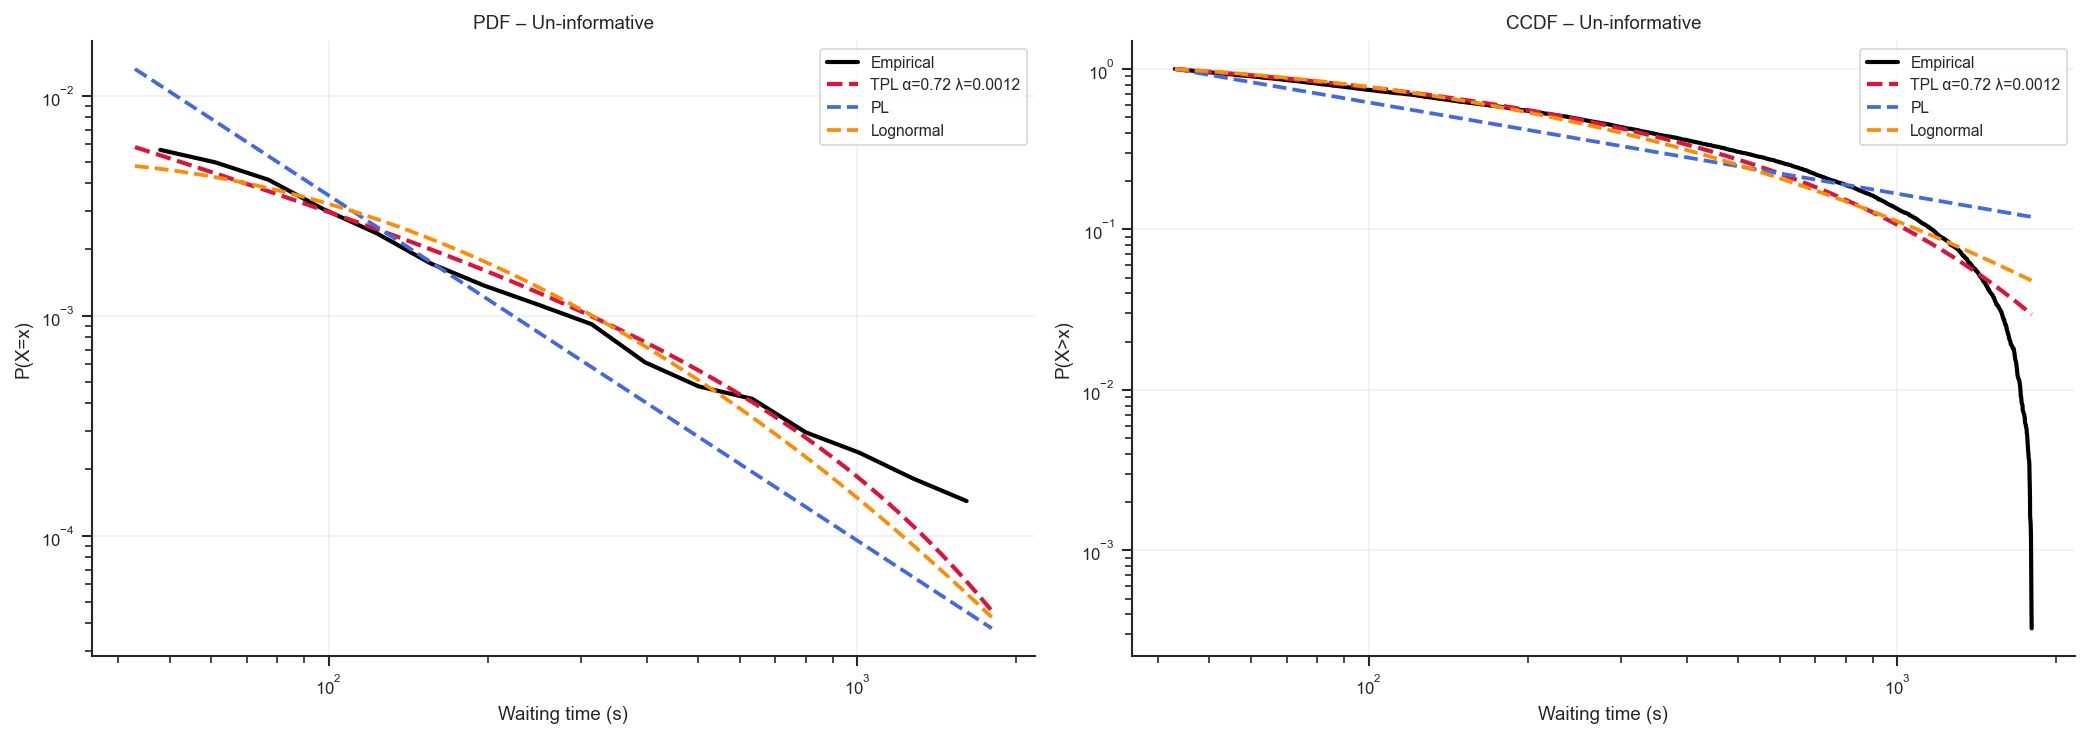


TYPE: INFORMATIVE
TPL FIT: Informative
  alpha=0.9884  lambda=0.001042  xmin=81.00  sigma=nan
  n=172  n_tail=111
  TPL vs PL: R=3.269 p=0.0000 * → TPL better
  TPL vs Lognormal: R=3.566 p=0.0004 * → TPL better
  TPL vs Exponential: R=2.323 p=0.0202 * → TPL better


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

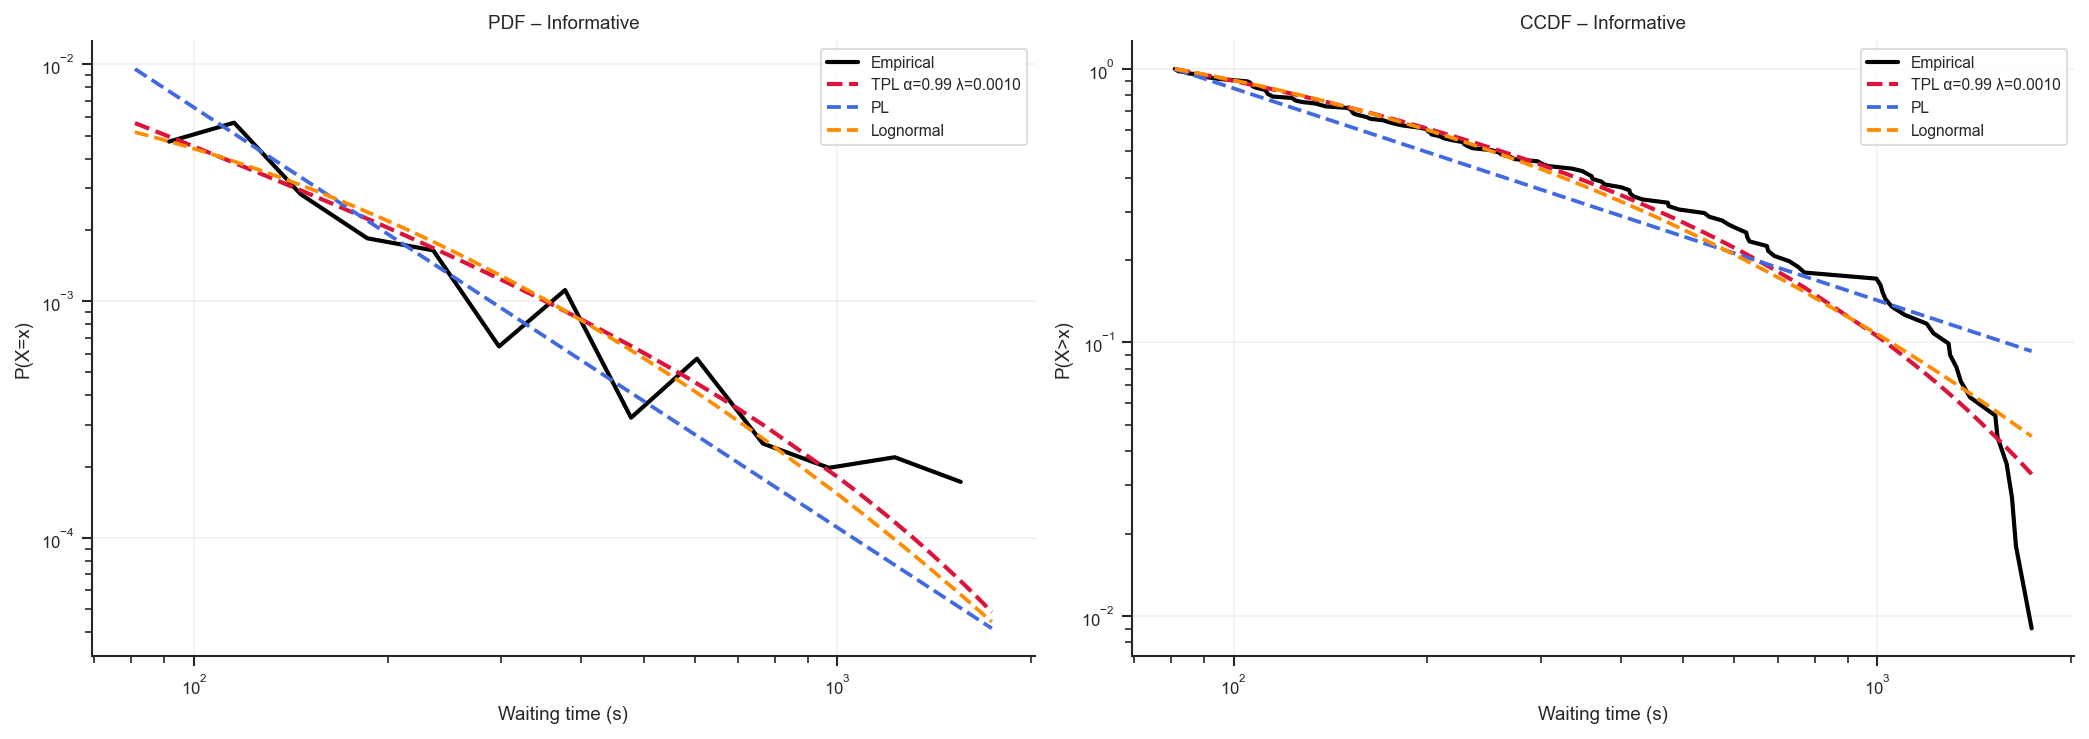


TYPE: MISINFORMATION

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'


TPL FIT: Misinformation
  alpha=0.5520  lambda=0.001902  xmin=249.00  sigma=nan
  n=3300  n_tail=705
  TPL vs PL: R=7.611 p=0.0000 * → TPL better
  TPL vs Lognormal: R=7.089 p=0.0000 * → TPL better
  TPL vs Exponential: R=1.573 p=0.1157  → no sig. diff


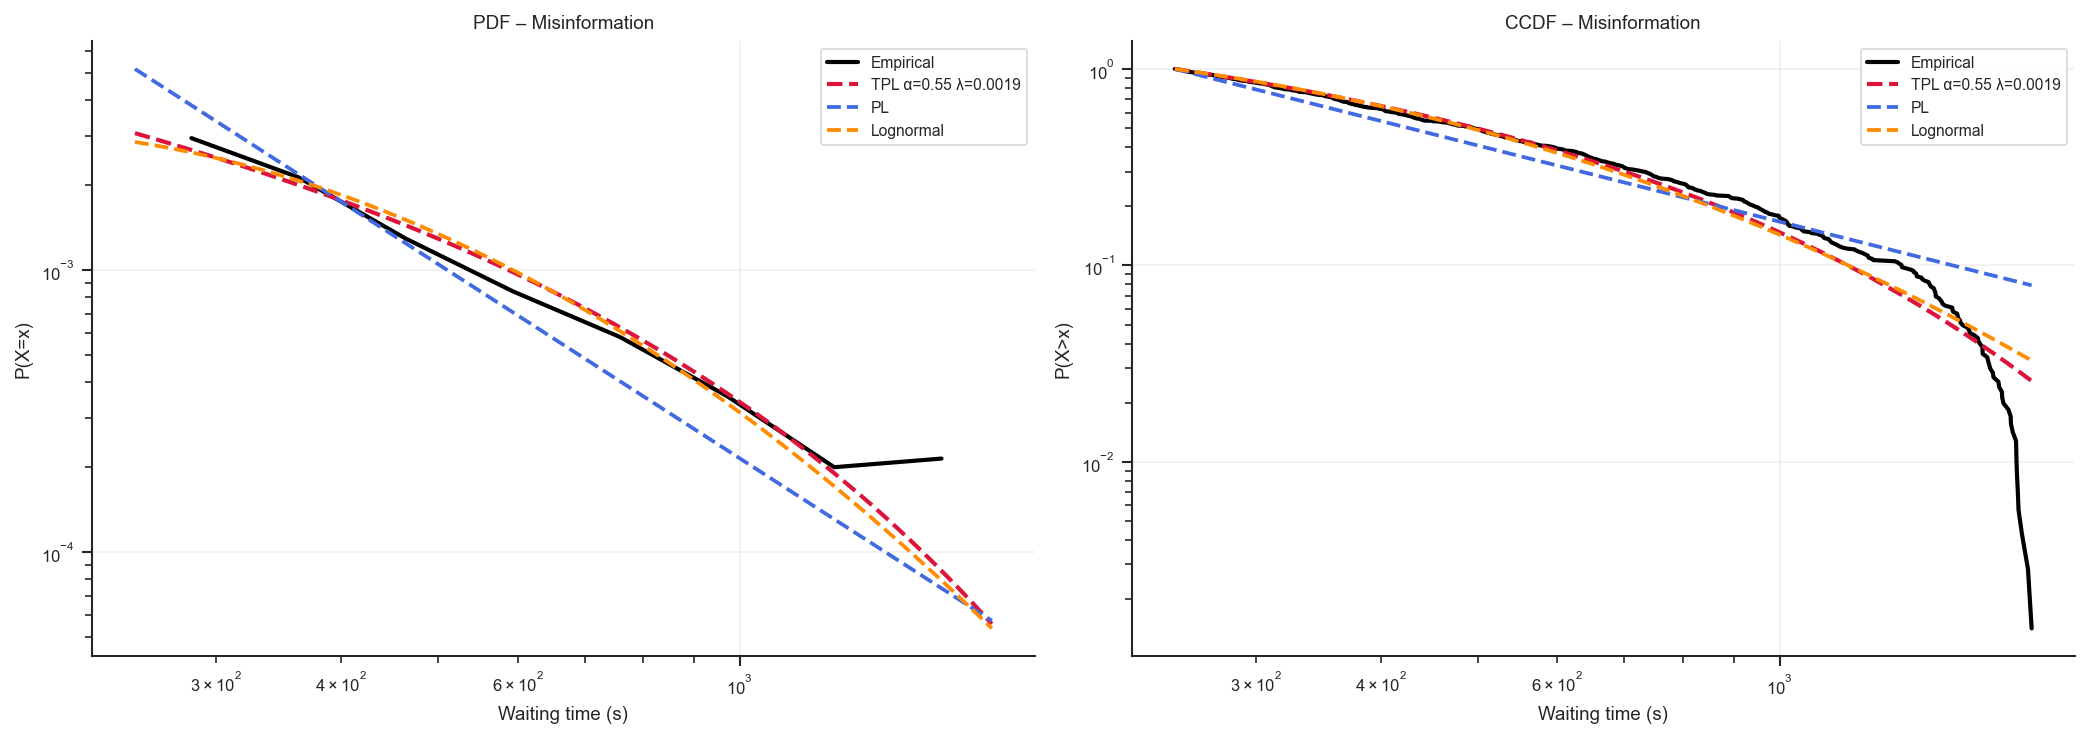


TYPE: MIXED
TPL FIT: Mixed
  alpha=1.3765  lambda=0.001225  xmin=104.00  sigma=nan
  n=903  n_tail=238
  TPL vs PL: R=3.392 p=0.0000 * → TPL better
  TPL vs Lognormal: R=4.169 p=0.0000 * → TPL better
  TPL vs Exponential: R=3.402 p=0.0007 * → TPL better


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

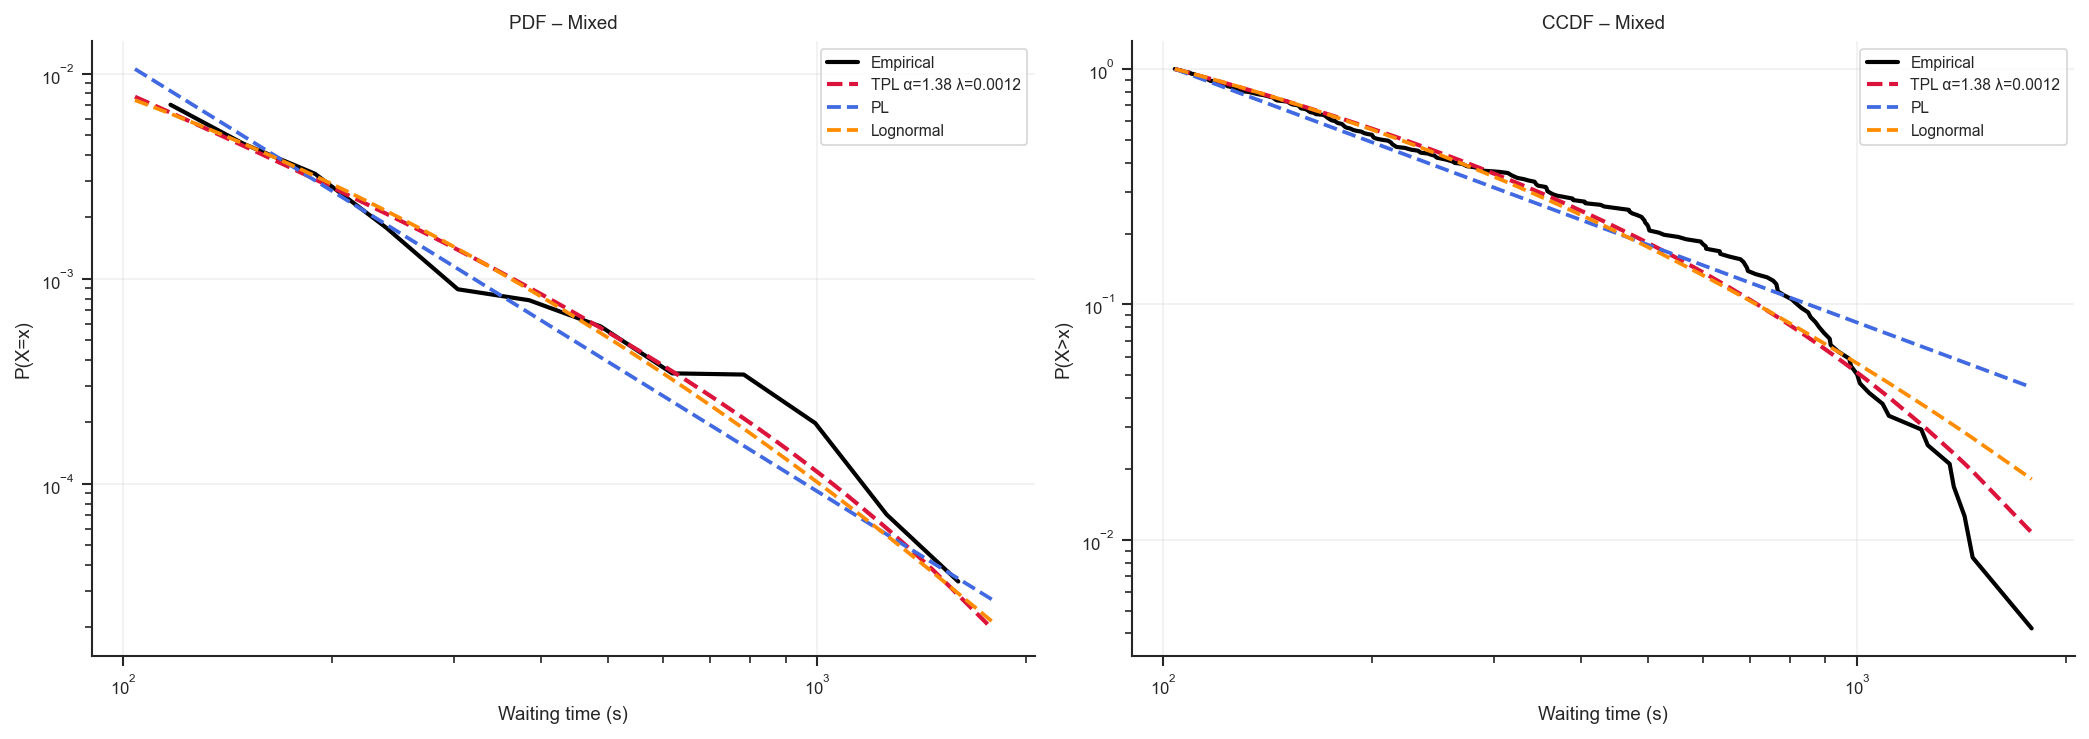


TYPE: ALL


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

TPL FIT: All
  alpha=0.8075  lambda=0.001231  xmin=50.00  sigma=nan
  n=13939  n_tail=8180
  TPL vs PL: R=34.054 p=0.0000 * → TPL better
  TPL vs Lognormal: R=28.347 p=0.0000 * → TPL better
  TPL vs Exponential: R=18.600 p=0.0000 * → TPL better


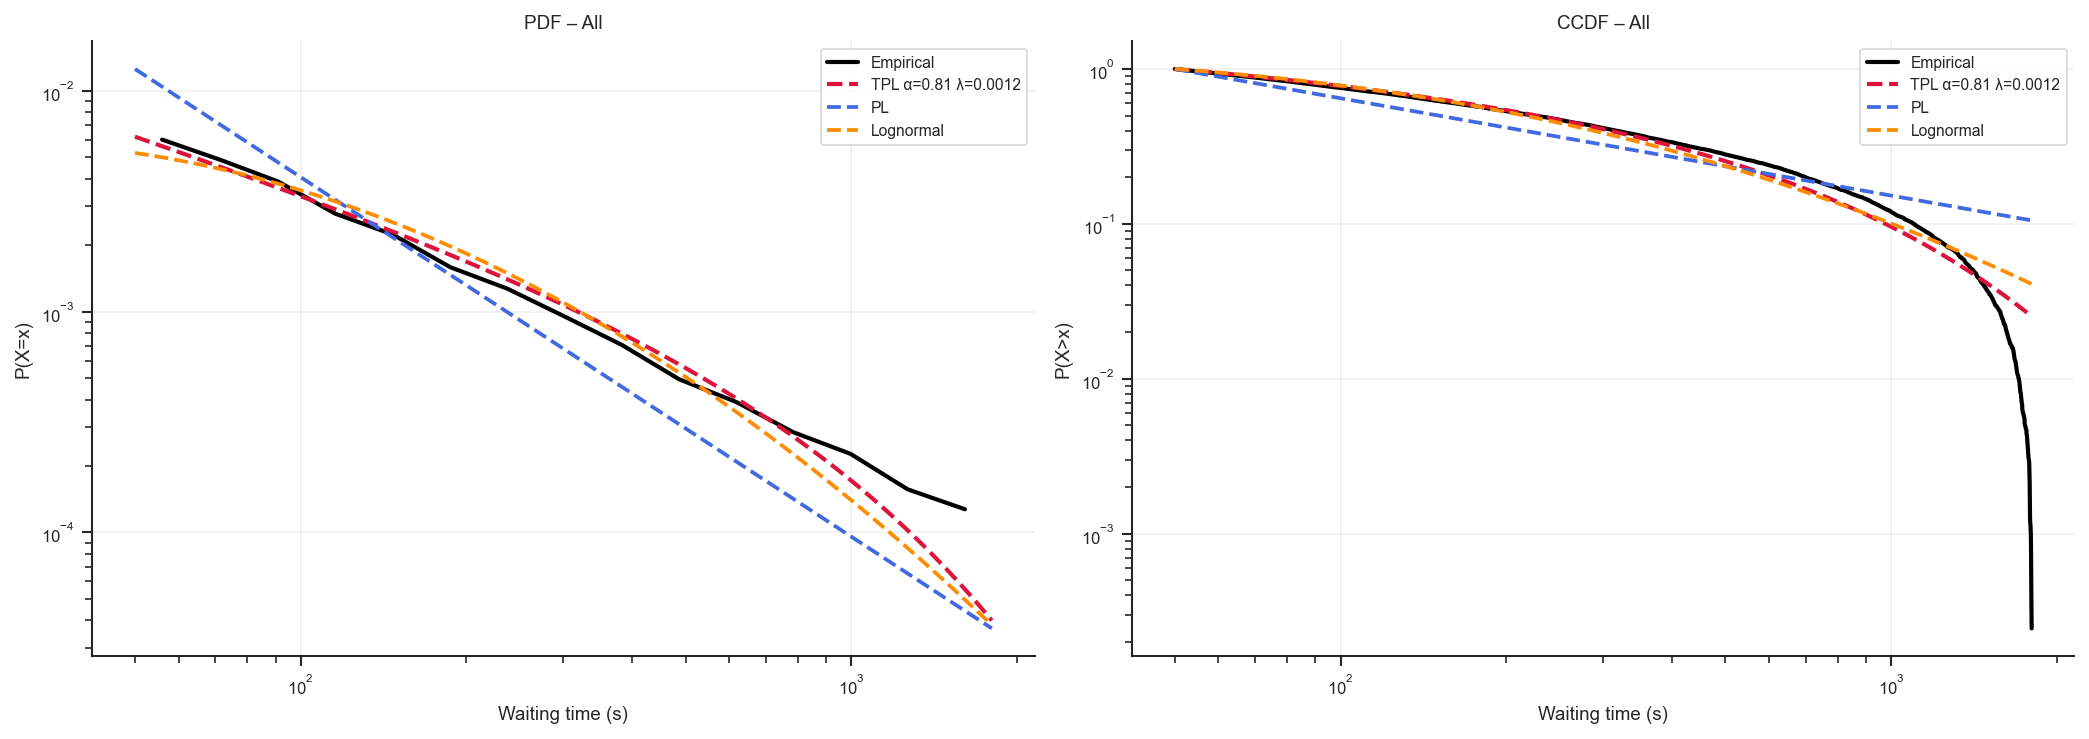

In [62]:
# Fit TPL to each cascade type (pooled waiting times)
fit_results = {}
for ctype in ["un-informative", "informative", "misinformation", "mixed", "all"]:
    print(f"\n{'='*70}")
    print(f"TYPE: {ctype.upper()}")
    fit_results[ctype] = fit_tpl_report(pooled_wts[ctype], label=ctype.capitalize(), discrete=False)


TYPE: UN-INFORMATIVE
EXPONENTIAL FIT: Un-informative
  lambda=0.003571  scale=280.0698  loc=1.0000
  KS stat=0.2397  p=0  n=9564


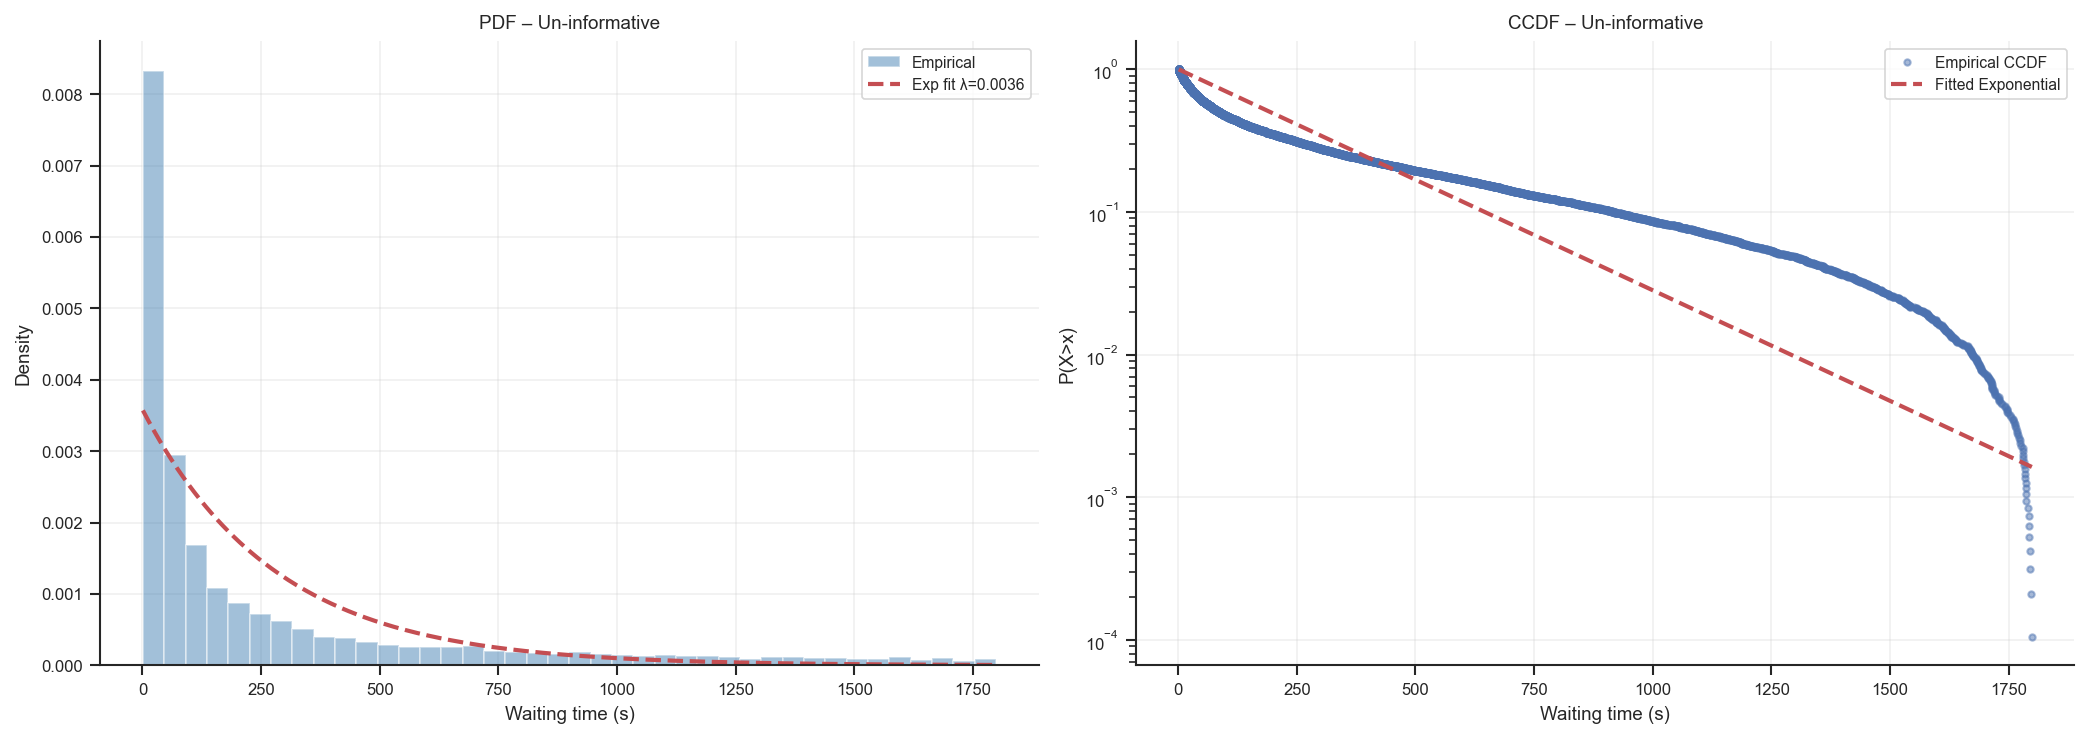


TYPE: INFORMATIVE
EXPONENTIAL FIT: Informative
  lambda=0.003328  scale=300.5174  loc=1.0000
  KS stat=0.1785  p=2.8905e-05  n=172


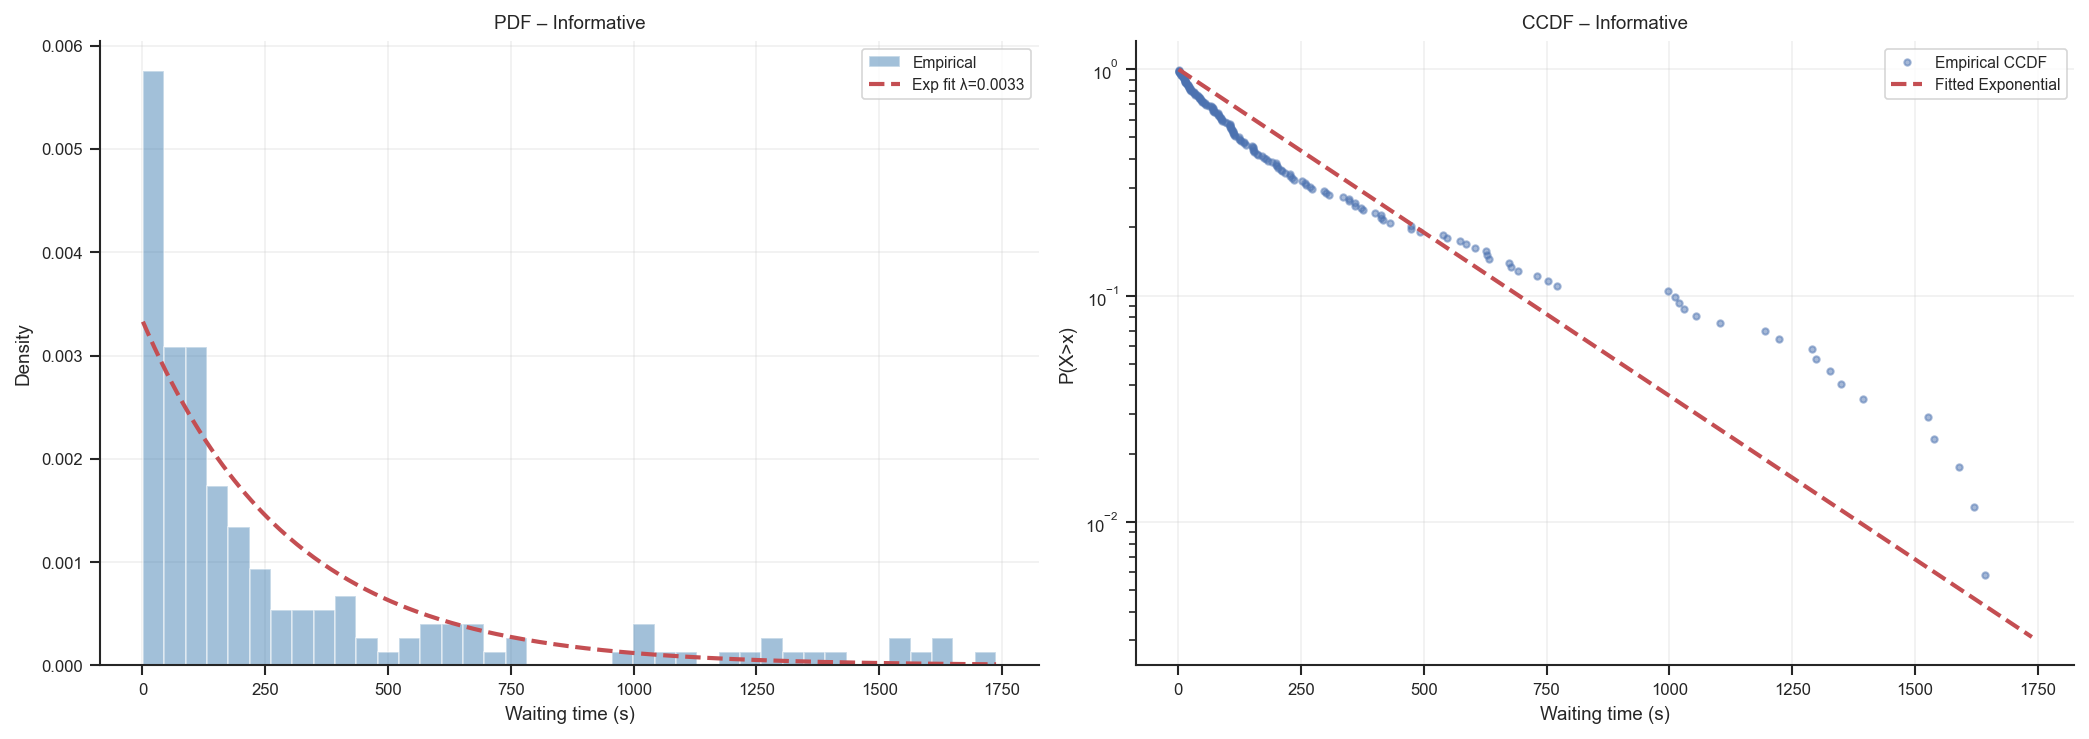


TYPE: MISINFORMATION
EXPONENTIAL FIT: Misinformation
  lambda=0.005444  scale=183.6985  loc=1.0000
  KS stat=0.2313  p=1.18057e-155  n=3300


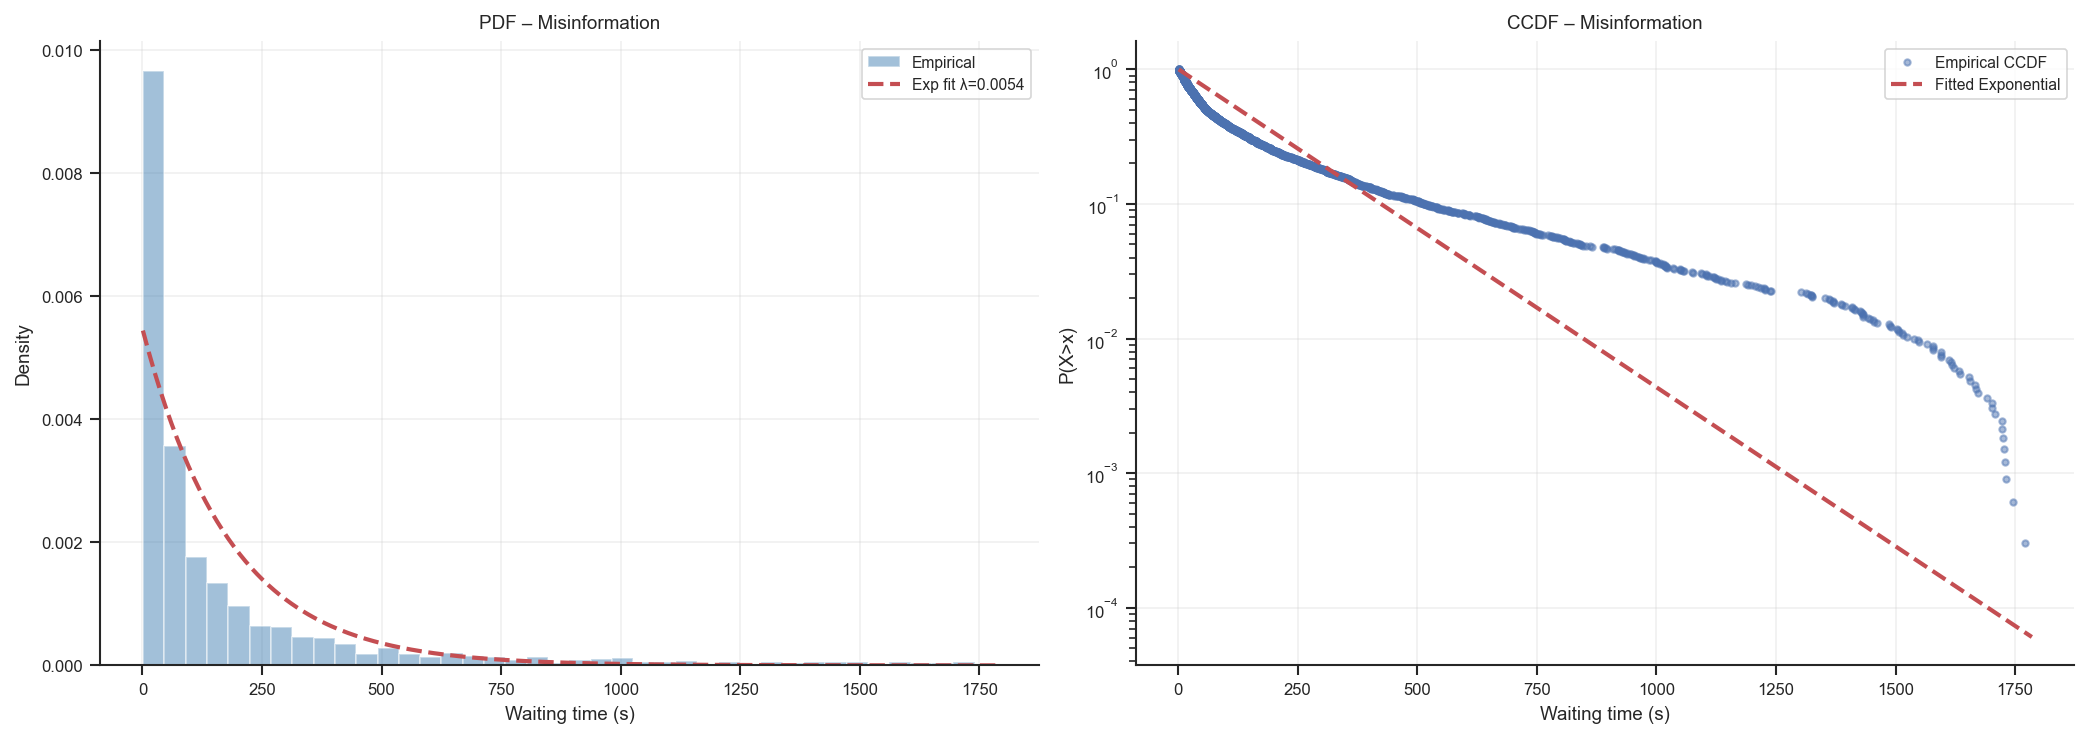


TYPE: MIXED
EXPONENTIAL FIT: Mixed
  lambda=0.008608  scale=116.1705  loc=1.0000
  KS stat=0.2068  p=2.38851e-34  n=903


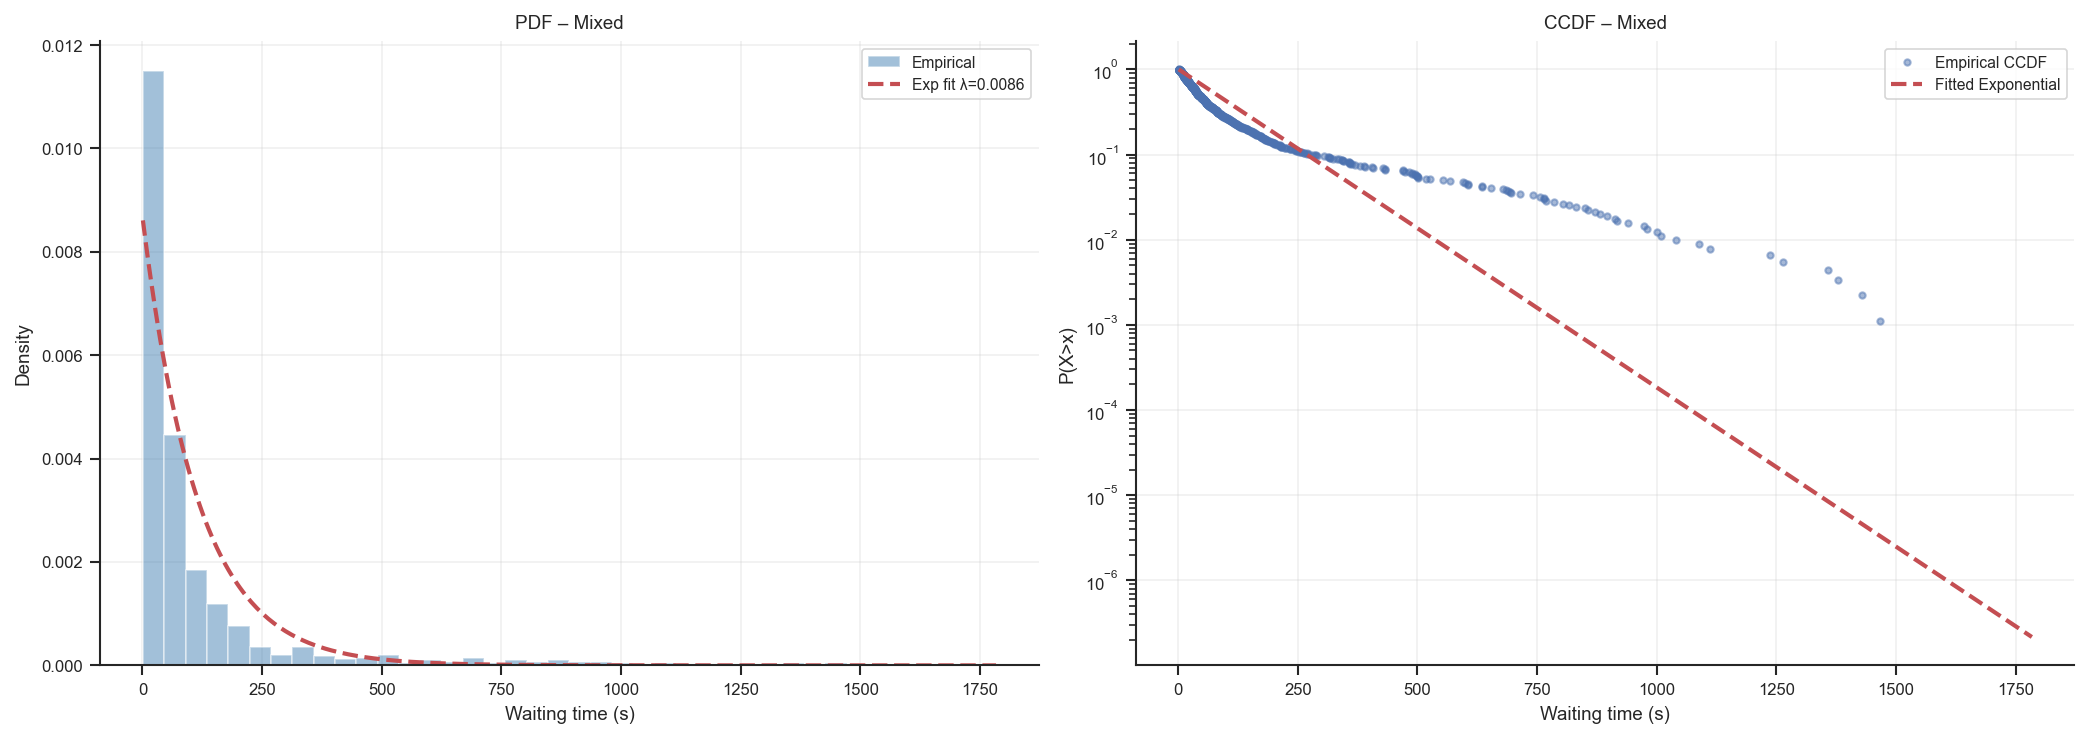

In [63]:
# Fit Poisson (exponential) to each cascade type
for ctype in ["un-informative", "informative", "misinformation", "mixed"]:
    print(f"\n{'='*70}")
    print(f"TYPE: {ctype.upper()}")
    fit_poisson_report(pooled_wts[ctype], label=ctype.capitalize(), discrete=False)

## CCDF comparison across cascade types

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

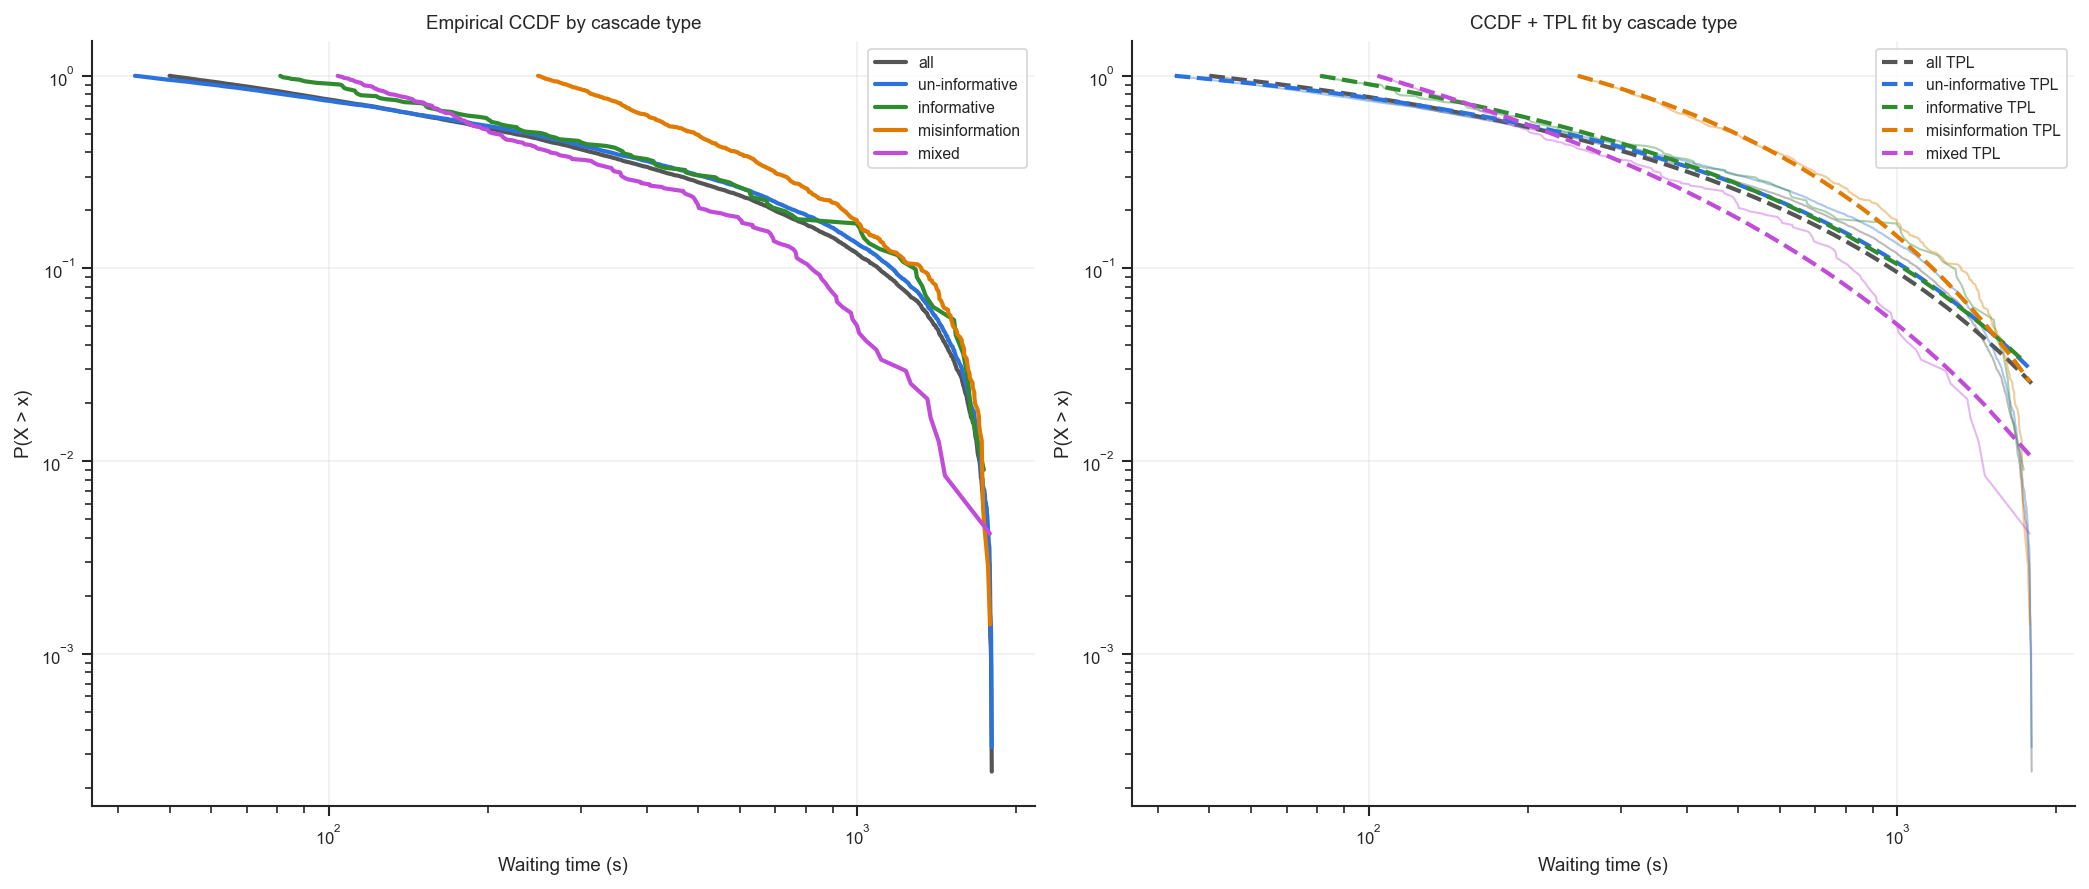

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

type_order = ["all", "un-informative", "informative", "misinformation", "mixed"]

for ctype in type_order:
    data = pooled_wts[ctype]
    if len(data) < 5:
        continue
    fit = powerlaw.Fit(data, discrete=False, verbose=False)

    # CCDF (log-log)
    fit.plot_ccdf(ax=axes[0], color=COLORS[ctype], lw=2, label=ctype)

    # Fitted TPL CCDF
    fit.truncated_power_law.plot_ccdf(
        ax=axes[1], color=COLORS[ctype], lw=2, ls="--", label=f"{ctype} TPL"
    )
    fit.plot_ccdf(ax=axes[1], color=COLORS[ctype], lw=1, alpha=0.4)

axes[0].set(xlabel="Waiting time (s)", ylabel="P(X > x)", title="Empirical CCDF by cascade type")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set(xlabel="Waiting time (s)", ylabel="P(X > x)", title="CCDF + TPL fit by cascade type")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/ccdf_by_type_all_cascades.png", dpi=300, bbox_inches="tight")
plt.show()

## KDE of per-cascade TPL alpha by type

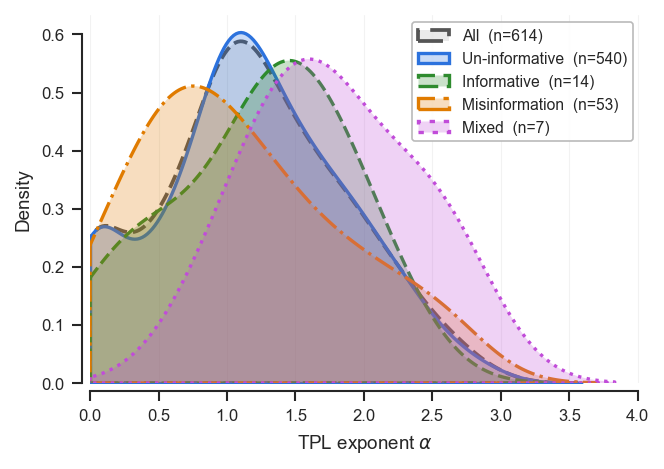

Saved figures/paper_kde_tpl_alpha_cascade_types.pdf


In [65]:
# Paper-ready: Distribution of TPL α per cascade type
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

sns.set_theme(style='ticks', context='paper')
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 9, 'axes.labelsize': 9, 'axes.titlesize': 9,
    'legend.fontsize': 7.5, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# Clip all alpha values to α >= 0 before KDE
all_alpha = cascade_fits["tpl_alpha"].dropna()
all_alpha_pos = all_alpha[all_alpha >= 0]

fig, ax = plt.subplots(figsize=(4.5, 3.2))

# "all" as dashed reference
sns.kdeplot(all_alpha_pos, ax=ax,
            label=f"All  (n={len(all_alpha_pos)})",
            color=COLORS["all"], fill=True, alpha=0.12,
            lw=1.8, linestyle="--", clip=(0, None))

# Per-type KDEs
labels = {
    "un-informative":       "Un-informative",
    "informative":    "Informative",
    "misinformation": "Misinformation",
    "mixed":          "Mixed",
}
linestyles = {
    "un-informative":       "-",
    "informative":    "--",
    "misinformation": "-.",
    "mixed":          ":",
}

for ctype in type_order:
    sub = cascade_fits[cascade_fits["cascade_type"] == ctype]["tpl_alpha"].dropna()
    sub_pos = sub[sub >= 0]
    if len(sub_pos) < 3:
        continue
    sns.kdeplot(sub_pos, ax=ax,
                label=f"{labels[ctype]}  (n={len(sub_pos)})",
                color=COLORS[ctype], fill=True, alpha=0.25,
                lw=1.6, linestyle=linestyles[ctype], clip=(0, None))

ax.set_xlim(left=0)
ax.set_xlabel(r"TPL exponent $\alpha$")
ax.set_ylabel("Density")
ax.legend(frameon=True, facecolor="white", edgecolor="0.7", framealpha=0.9)
ax.grid(axis='x', alpha=0.25, linewidth=0.5)
sns.despine(ax=ax, trim=True, offset=4)

fig.tight_layout()
fig.savefig("figures/paper_kde_tpl_alpha_cascade_types.pdf", format="pdf", bbox_inches="tight")
plt.show()
print("Saved figures/paper_kde_tpl_alpha_cascade_types.pdf")


Bootstrap comparison against 'all' (n=614, N_boot=2000)

UN-INFORMATIVE  (n=540)
  mean α = 1.1788  vs  all mean α = 1.1792  →  Δμ = -0.0004
  KS distance  D = 0.0134  →  bootstrap p = 1.0000  (n.s.)
  Mean diff   Δμ = -0.0004  →  bootstrap p = 0.9850  (n.s.)

INFORMATIVE  (n=14)
  mean α = 1.2191  vs  all mean α = 1.1792  →  Δμ = +0.0399
  KS distance  D = 0.1673  →  bootstrap p = 0.7705  (n.s.)
  Mean diff   Δμ = +0.0399  →  bootstrap p = 0.8280  (n.s.)

MISINFORMATION  (n=53)
  mean α = 1.0945  vs  all mean α = 1.1792  →  Δμ = -0.0847
  KS distance  D = 0.1886  →  bootstrap p = 0.0440  *
  Mean diff   Δμ = -0.0847  →  bootstrap p = 0.3850  (n.s.)

MIXED  (n=7)
  mean α = 1.7752  vs  all mean α = 1.1792  →  Δμ = +0.5960
  KS distance  D = 0.4956  →  bootstrap p = 0.0470  *
  Mean diff   Δμ = +0.5960  →  bootstrap p = 0.0250  *



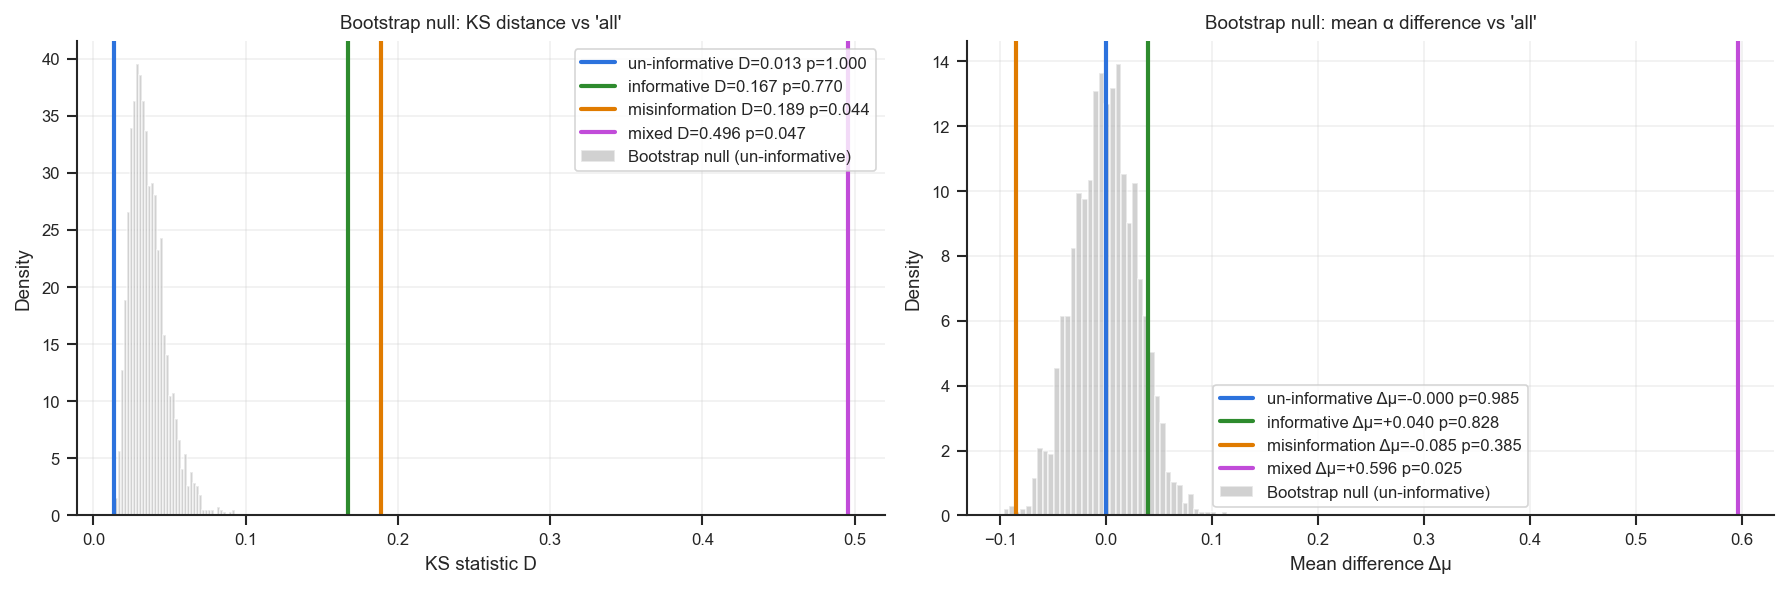

In [66]:
# Bootstrap comparison of each cascade type vs the overall (all) distribution
# For each type t:
#   H0: the alpha values of type t come from the same distribution as "all"
#   Statistic: observed KS distance D(t, all) and mean difference Δμ = mean(t) - mean(all)
#   Null: sample n_t values from "all" with replacement, compute the same statistics
#   p-value: fraction of bootstrap statistics >= observed (two-sided for Δμ)

import numpy as np
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

N_BOOT = 2000
rng    = np.random.default_rng(42)

all_alpha = cascade_fits["tpl_alpha"].dropna().values
type_order_cmp = ["un-informative", "informative", "misinformation", "mixed"]

print(f"Bootstrap comparison against 'all' (n={len(all_alpha)}, N_boot={N_BOOT})")
print("=" * 75)

results = {}
for ctype in type_order_cmp:
    grp = cascade_fits[cascade_fits["cascade_type"] == ctype]["tpl_alpha"].dropna().values
    n   = len(grp)
    if n < 3:
        print(f"\n{ctype}: too few samples (n={n}), skipping.")
        continue

    # Observed statistics
    ks_obs, ks_p_scipy = ks_2samp(grp, all_alpha)
    dm_obs = grp.mean() - all_alpha.mean()

    # Bootstrap null: draw n values from all_alpha, compute KS and Δμ
    boot_ks = np.zeros(N_BOOT)
    boot_dm = np.zeros(N_BOOT)
    for b in range(N_BOOT):
        sample    = rng.choice(all_alpha, size=n, replace=True)
        boot_ks[b] = ks_2samp(sample, all_alpha).statistic
        boot_dm[b] = sample.mean() - all_alpha.mean()

    p_ks = np.mean(boot_ks >= ks_obs)
    p_dm = np.mean(np.abs(boot_dm) >= np.abs(dm_obs))   # two-sided

    def stars(p):
        return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "(n.s.)"

    print(f"\n{ctype.upper()}  (n={n})")
    print(f"  mean α = {grp.mean():.4f}  vs  all mean α = {all_alpha.mean():.4f}  →  Δμ = {dm_obs:+.4f}")
    print(f"  KS distance  D = {ks_obs:.4f}  →  bootstrap p = {p_ks:.4f}  {stars(p_ks)}")
    print(f"  Mean diff   Δμ = {dm_obs:+.4f}  →  bootstrap p = {p_dm:.4f}  {stars(p_dm)}")

    results[ctype] = dict(n=n, mean=grp.mean(), ks=ks_obs,
                          p_ks=p_ks, delta_mu=dm_obs, p_dm=p_dm,
                          boot_ks=boot_ks, boot_dm=boot_dm)

print("\n" + "=" * 75)

# ── Visualisation: bootstrap null distributions ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ctype, res in results.items():
    c = COLORS[ctype]
    axes[0].axvline(res["ks"],      color=c, lw=2, label=f"{ctype} D={res['ks']:.3f} p={res['p_ks']:.3f}")
    axes[1].axvline(res["delta_mu"], color=c, lw=2, label=f"{ctype} Δμ={res['delta_mu']:+.3f} p={res['p_dm']:.3f}")

# Plot one representative bootstrap null (un-informative, largest group)
ref = results.get("un-informative", next(iter(results.values())))
axes[0].hist(ref["boot_ks"], bins=40, color="0.7", alpha=0.6, density=True, label="Bootstrap null (un-informative)")
axes[1].hist(ref["boot_dm"], bins=40, color="0.7", alpha=0.6, density=True, label="Bootstrap null (un-informative)")

axes[0].set_xlabel("KS statistic D")
axes[0].set_ylabel("Density")
axes[0].set_title("Bootstrap null: KS distance vs 'all'")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Mean difference Δμ")
axes[1].set_ylabel("Density")
axes[1].set_title("Bootstrap null: mean α difference vs 'all'")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/bootstrap_vs_all.png", dpi=300, bbox_inches="tight")
plt.show()


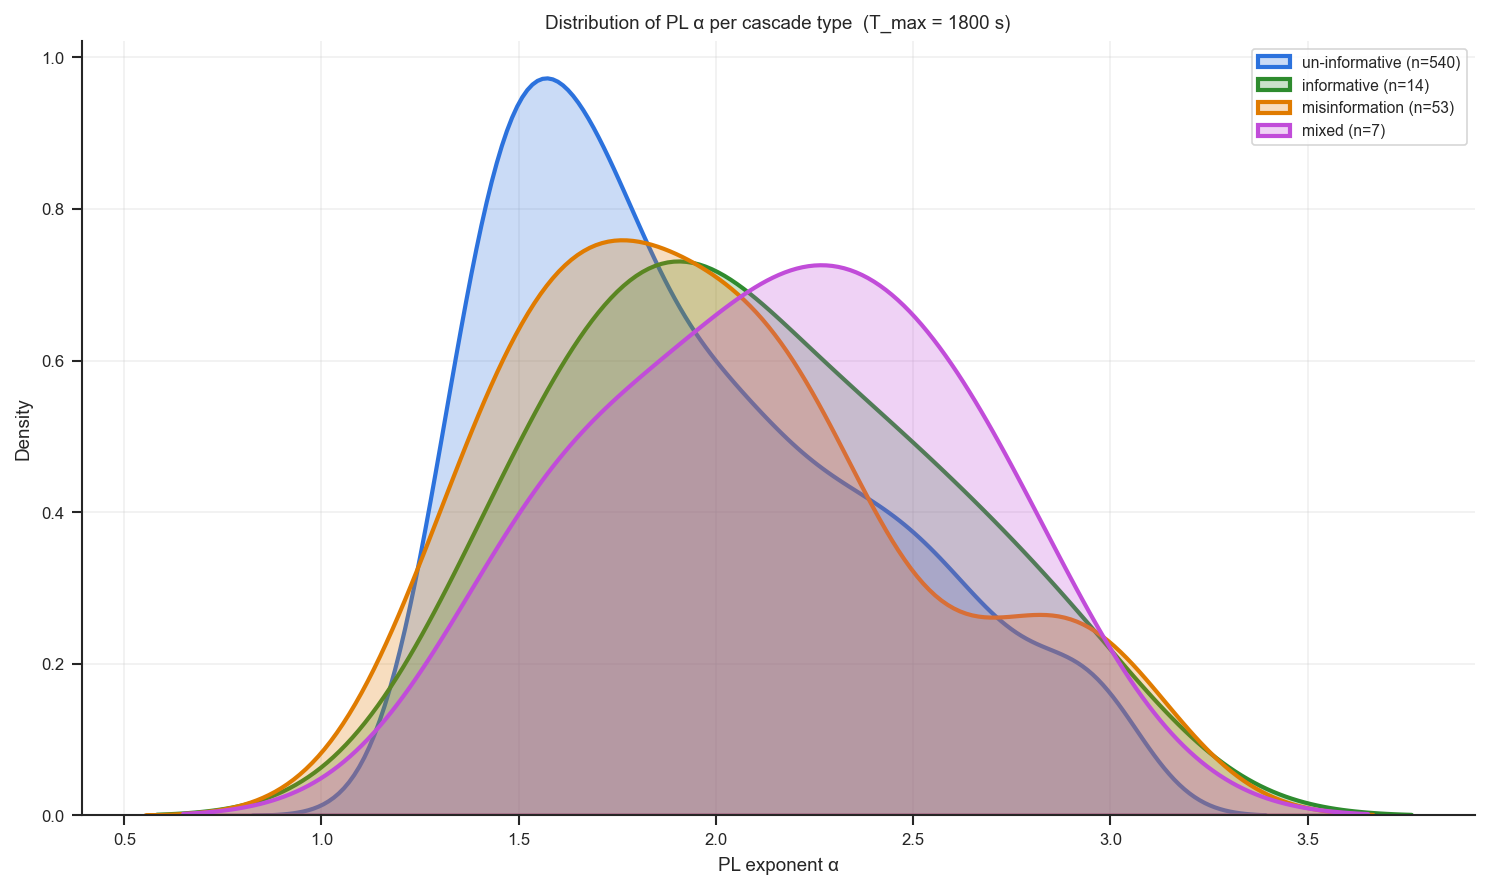

In [67]:
# KDE of per-cascade PL alpha
plt.figure(figsize=(10, 6))

for ctype in type_order:
    sub_alpha = cascade_fits[cascade_fits["cascade_type"] == ctype]["pl_alpha"].dropna()
    if len(sub_alpha) < 3:
        continue
    sns.kdeplot(
        sub_alpha, label=f"{ctype} (n={len(sub_alpha)})",
        color=COLORS[ctype], fill=True, alpha=0.25, lw=2,
    )

plt.xlabel("PL exponent α")
plt.ylabel("Density")
plt.title(f"Distribution of PL α per cascade type  (T_max = {OPTIMAL_T_MAX} s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/kde_pl_alpha_all_cascades.png", dpi=300, bbox_inches="tight")
plt.show()

## KDE of per-cascade TPL lambda (exponential cutoff) by type

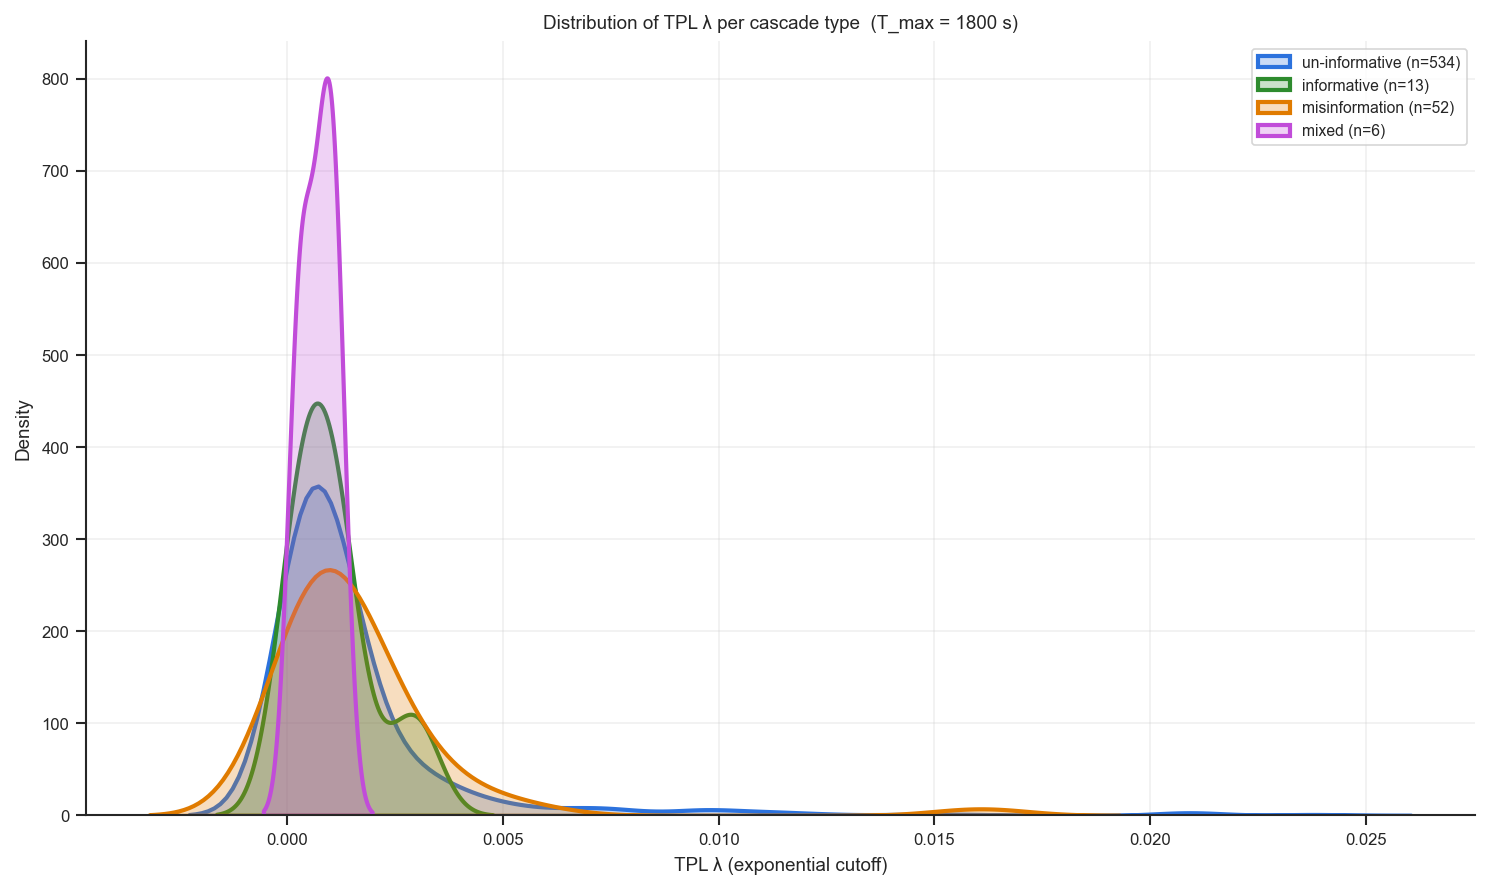

In [68]:
plt.figure(figsize=(10, 6))

for ctype in type_order:
    sub_lam = cascade_fits[cascade_fits["cascade_type"] == ctype]["tpl_lambda"].dropna()
    sub_lam = sub_lam[sub_lam < sub_lam.quantile(0.99)]  # remove extreme outliers for clarity
    if len(sub_lam) < 3:
        continue
    sns.kdeplot(
        sub_lam, label=f"{ctype} (n={len(sub_lam)})",
        color=COLORS[ctype], fill=True, alpha=0.25, lw=2,
    )

plt.xlabel("TPL λ (exponential cutoff)")
plt.ylabel("Density")
plt.title(f"Distribution of TPL λ per cascade type  (T_max = {OPTIMAL_T_MAX} s)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/kde_tpl_lambda_all_cascades.png", dpi=300, bbox_inches="tight")
plt.show()

## Cascade size distribution by type

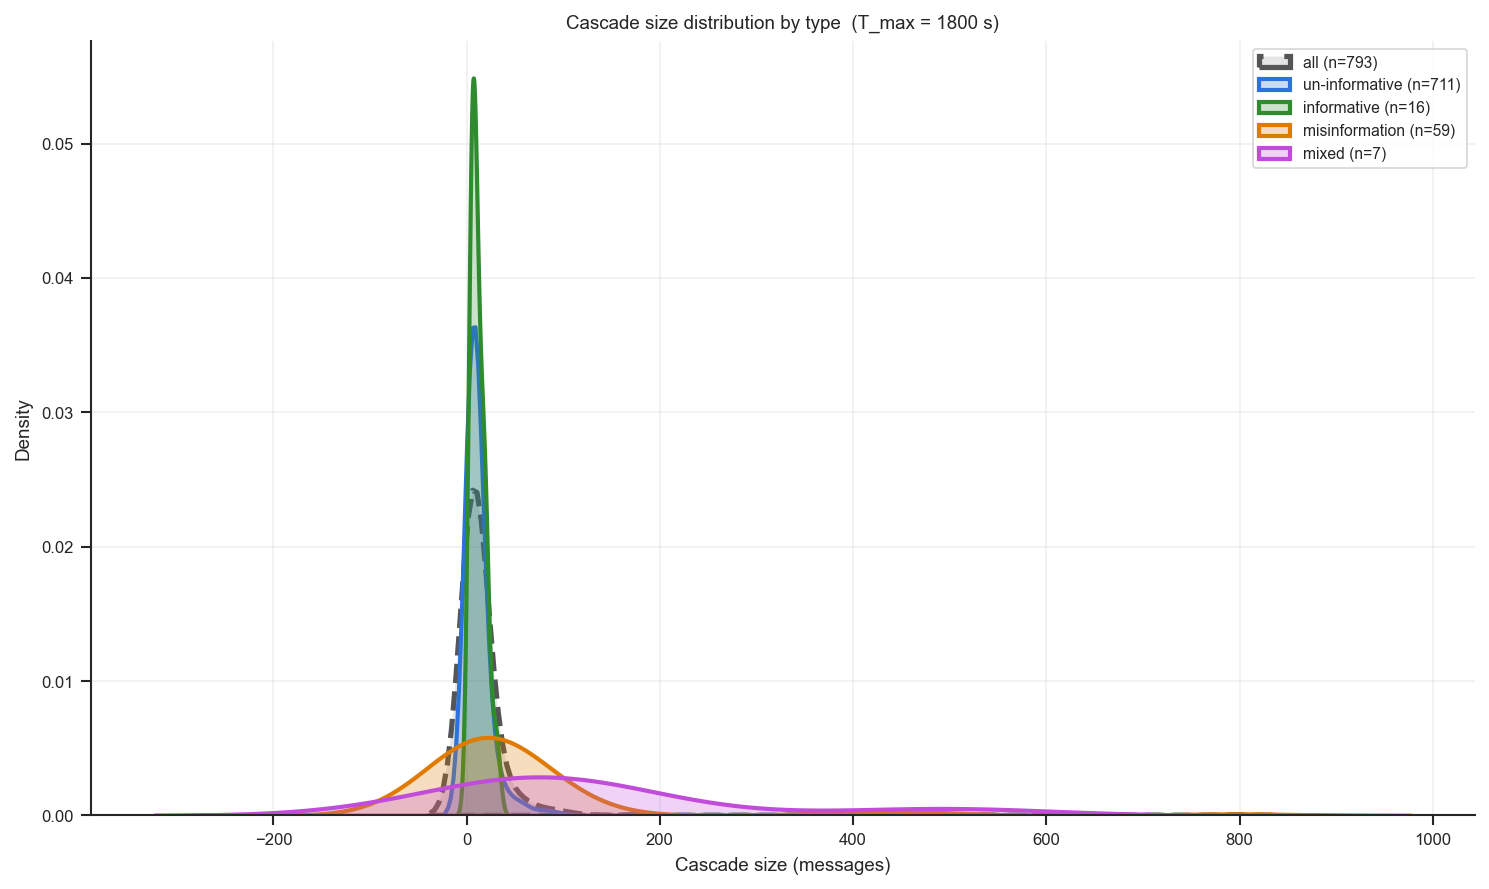

In [69]:
fig, ax = plt.subplots(figsize=(10, 6))

all_size = cascade_fits["cascade_size"].dropna()
sns.kdeplot(all_size, label=f"all (n={len(all_size)})",
            color=COLORS["all"], fill=True, alpha=0.15, lw=2.5, linestyle="--", ax=ax)

for ctype in type_order:
    sub = cascade_fits[cascade_fits["cascade_type"] == ctype]["cascade_size"].dropna()
    if len(sub) < 3:
        continue
    sns.kdeplot(sub, label=f"{ctype} (n={len(sub)})", color=COLORS[ctype], fill=True, alpha=0.25, lw=2, ax=ax)

ax.set(xlabel="Cascade size (messages)", ylabel="Density",
       title=f"Cascade size distribution by type  (T_max = {OPTIMAL_T_MAX} s)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/kde_cascade_size_all_cascades.png", dpi=300, bbox_inches="tight")
plt.show()

## Summary statistics table

In [70]:
summary_rows = []
for ctype in type_order + ["all"]:
    sub = cascade_fits if ctype == "all" else cascade_fits[cascade_fits["cascade_type"] == ctype]
    wts = pooled_wts.get(ctype, np.array([]))
    summary_rows.append({
        "type":         ctype,
        "n_cascades":   len(sub),
        "mean_size":    sub["cascade_size"].mean(),
        "n_wts":        len(wts),
        "mean_tpl_α":   sub["tpl_alpha"].mean(),
        "std_tpl_α":    sub["tpl_alpha"].std(),
        "mean_tpl_λ":   sub["tpl_lambda"].mean(),
        "mean_pl_α":    sub["pl_alpha"].mean(),
    })

summary_df = pd.DataFrame(summary_rows).set_index("type")
print(f"Summary  (T_max = {OPTIMAL_T_MAX} s)")
print(summary_df.round(4).to_string())

Summary  (T_max = 1800 s)
                n_cascades  mean_size  n_wts  mean_tpl_α  std_tpl_α  mean_tpl_λ  mean_pl_α
type                                                                                      
all                    793    17.8033  13939      1.1792     0.6931      0.0025     1.9399
un-informative         711    13.4613   9564      1.1788     0.6887      0.0026     1.9276
informative             16    11.4375    172      1.2191     0.6491      0.0027     2.0876
misinformation          59    58.1186   3300      1.0945     0.7382      0.0019     1.9968
mixed                    7   133.5714    903      1.7752     0.5927      0.0008     2.1577
all                    793    17.8033  13939      1.1792     0.6931      0.0025     1.9399


## Example: inspect the 3 largest misinformation cascades


--- Misinformation cascade #1 ---
  Channel: Asistencia Informática/Soporte EAT
  Size: 798 messages
  Duration: 2024-11-02 10:16:31+00:00 → 2024-11-03 00:04:51+00:00
  Waiting times (n=782): mean=63.6s  median=29.0s  max=1413.0s
TPL FIT: Misinformation cascade #1
  alpha=1.8190  lambda=0.001557  xmin=70.00  sigma=nan
  n=782  n_tail=186
  TPL vs PL: R=1.918 p=0.0068 * → TPL better
  TPL vs Lognormal: R=1.593 p=0.1113  → no sig. diff
  TPL vs Exponential: R=2.612 p=0.0090 * → TPL better


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

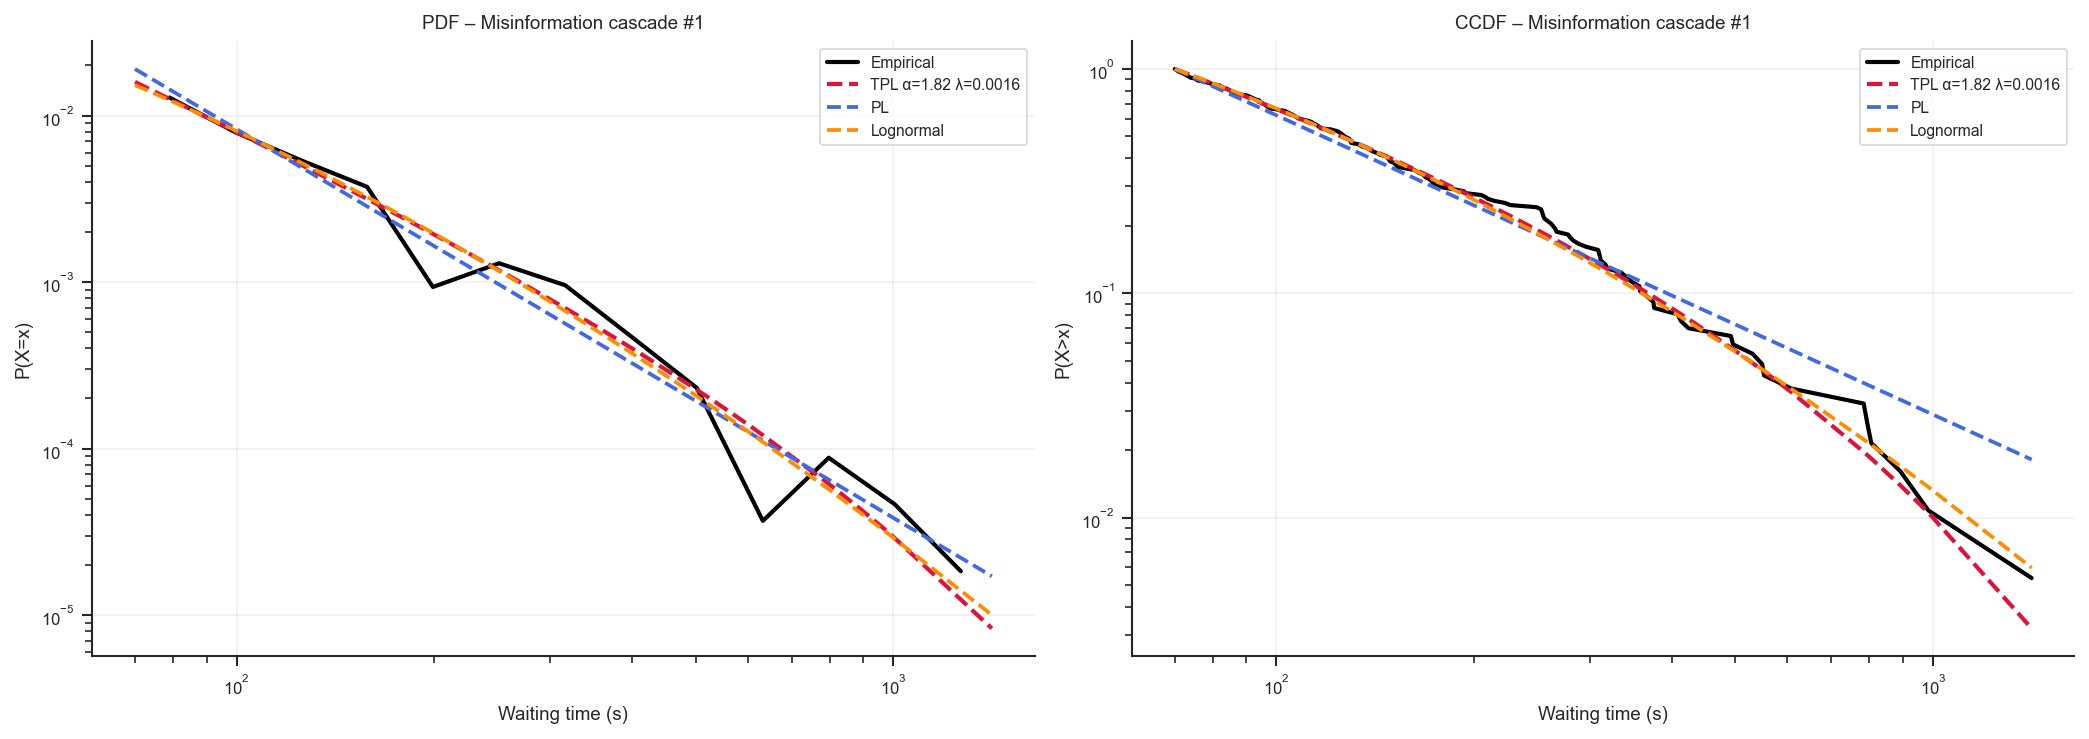


--- Misinformation cascade #2 ---
  Channel: Bienvenid@s a la Red de Voluntari@s (leed primero)
  Size: 461 messages
  Duration: 2024-11-03 06:11:33+00:00 → 2024-11-04 01:16:17+00:00
  Waiting times (n=450): mean=152.6s  median=60.5s  max=1452.0s
TPL FIT: Misinformation cascade #2
  alpha=0.7247  lambda=0.002386  xmin=129.00  sigma=nan
  n=450  n_tail=143
  TPL vs PL: R=3.588 p=0.0000 * → TPL better
  TPL vs Lognormal: R=2.281 p=0.0226 * → TPL better
  TPL vs Exponential: R=1.128 p=0.2592  → no sig. diff


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

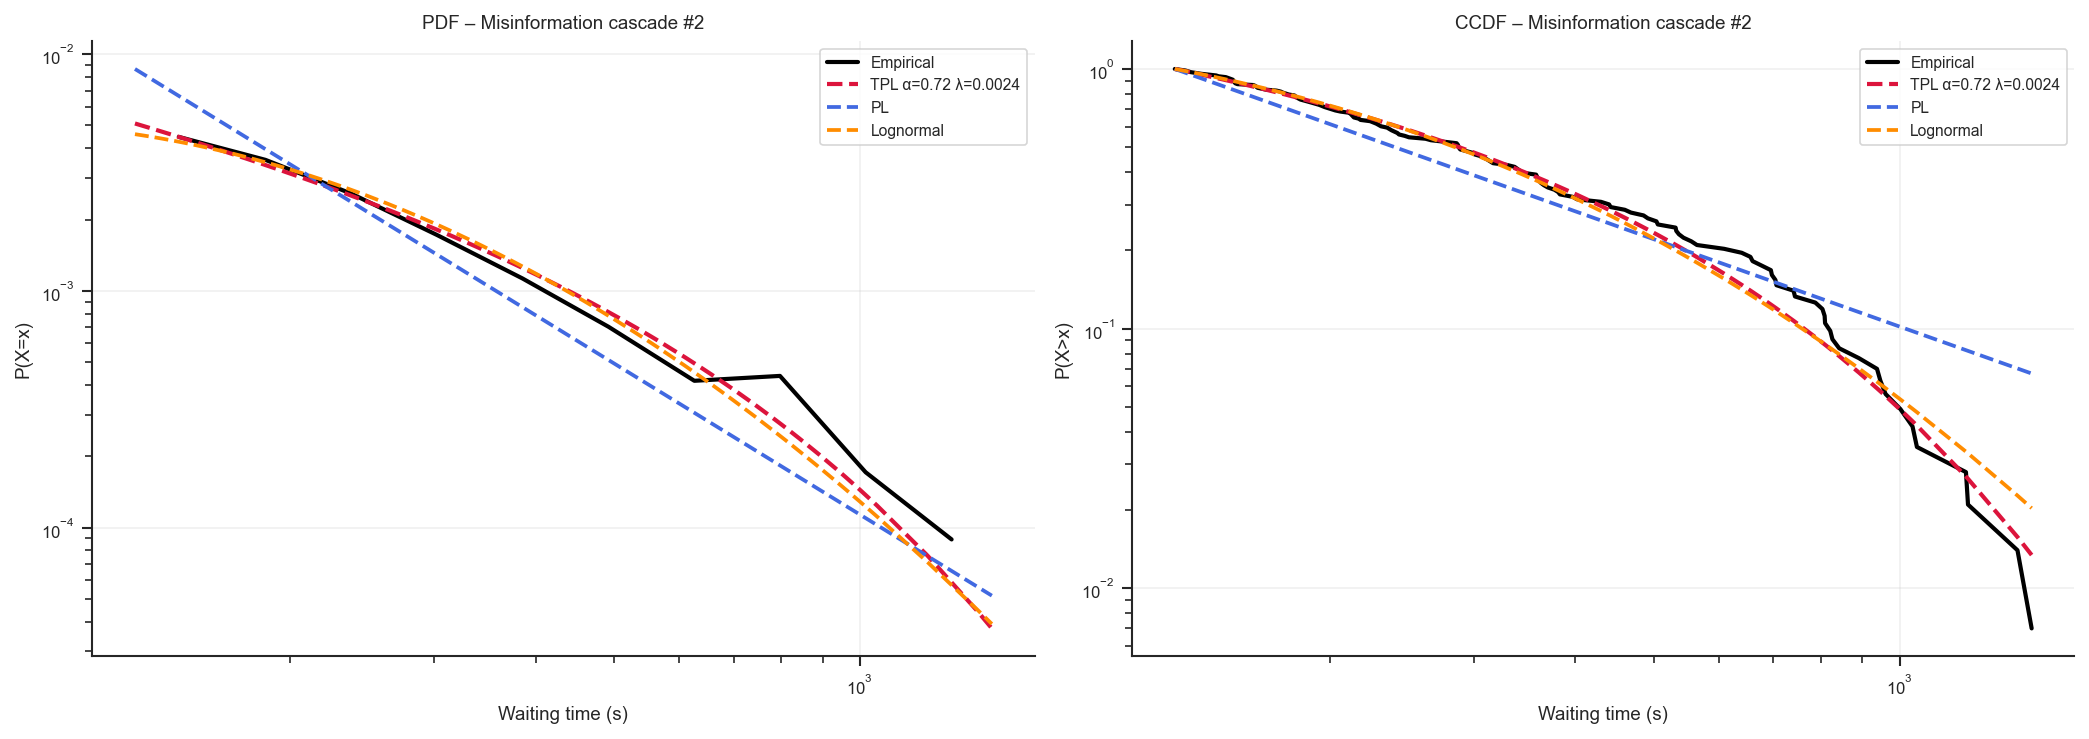


--- Misinformation cascade #3 ---
  Channel: Bienvenid@s a la Red de Voluntari@s (leed primero)
  Size: 450 messages
  Duration: 2024-11-04 06:53:30+00:00 → 2024-11-05 00:07:53+00:00
  Waiting times (n=436): mean=142.3s  median=60.5s  max=1312.0s
TPL FIT: Misinformation cascade #3
  alpha=0.1061  lambda=0.004459  xmin=274.00  sigma=nan
  n=436  n_tail=74
  TPL vs PL: R=1.914 p=0.0031 * → TPL better
  TPL vs Lognormal: R=1.515 p=0.1298  → no sig. diff
  TPL vs Exponential: R=0.046 p=0.9631  → no sig. diff


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

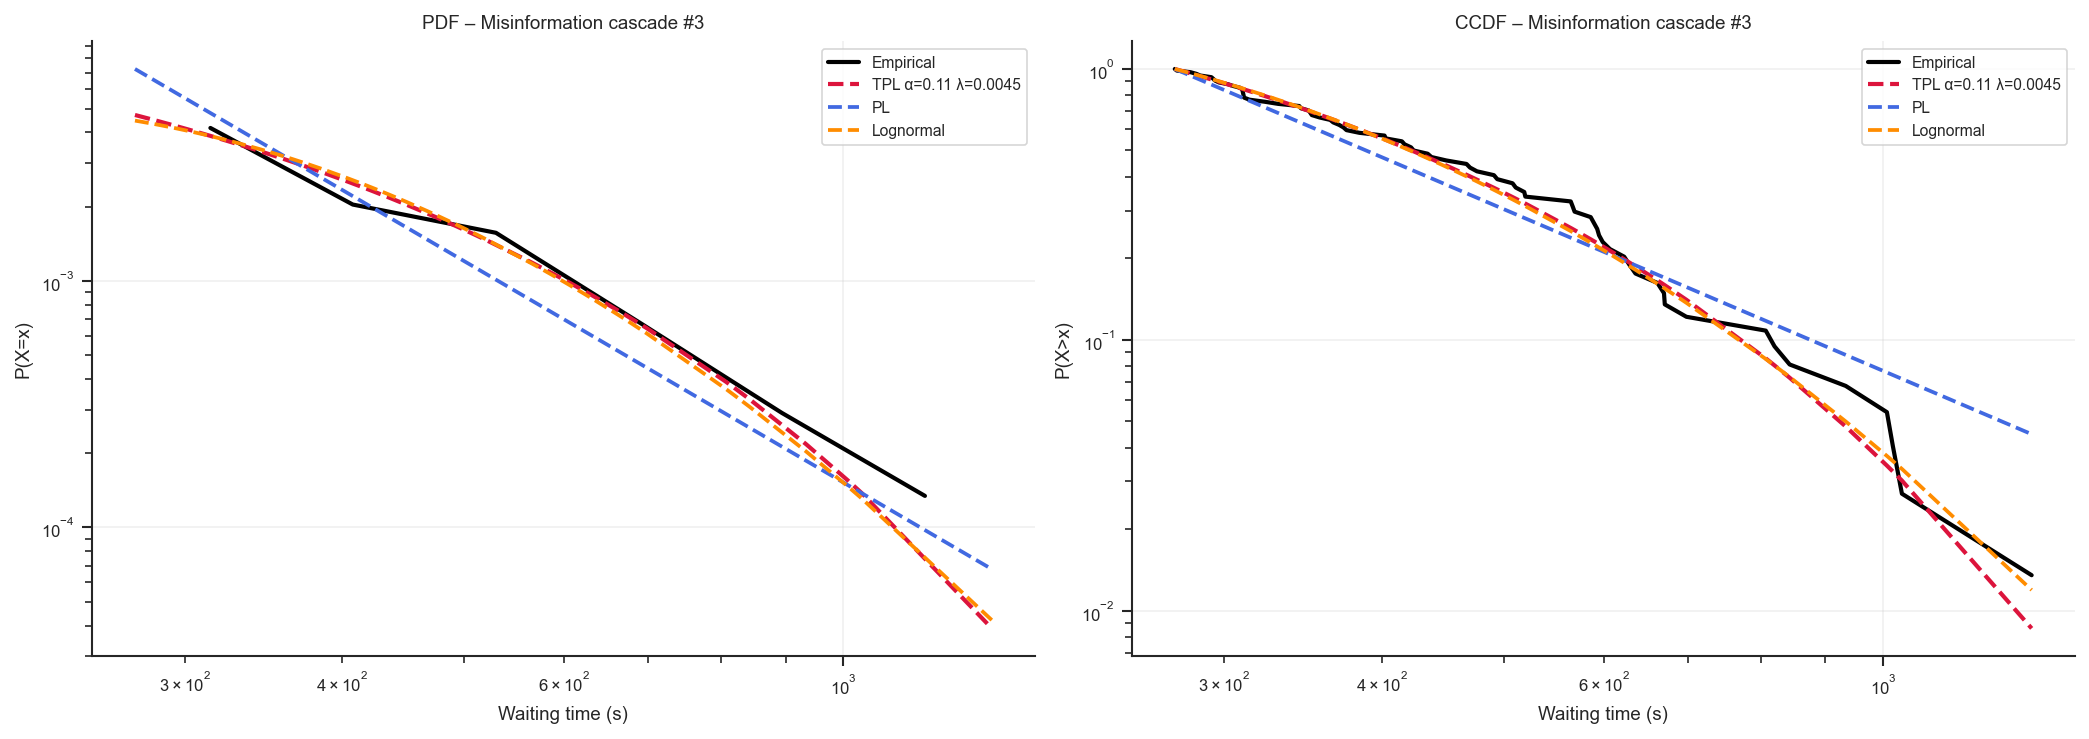

In [71]:
mis_cascades = cascades[cascades["cascade_type"] == "misinformation"].sort_values("size", ascending=False)

for i, (_, row) in enumerate(mis_cascades.head(3).iterrows()):
    print(f"\n--- Misinformation cascade #{i+1} ---")
    print(f"  Channel: {row['topic_name']}")
    print(f"  Size: {row['size']} messages")
    print(f"  Duration: {row['start_time']} → {row['end_time']}")
    wts = [w for w in row["waiting_times"] if np.isfinite(w) and w > 0]
    print(f"  Waiting times (n={len(wts)}): mean={np.mean(wts):.1f}s  median={np.median(wts):.1f}s  max={np.max(wts):.1f}s")
    fit_tpl_report(wts, label=f"Misinformation cascade #{i+1}", discrete=False)